<a href="https://colab.research.google.com/github/hyunkyung31/coronary-ai-ml-dl/blob/main/hyunkyung/11_AngioCAD_classification_gradcam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title 00. Google Drive 연결 및 저장 경로 설정

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import unicodedata


MYDRIVE = Path("/content/drive/MyDrive")


def normalized_name(path):
    return unicodedata.normalize("NFC", path.name)


macgyver_candidates = [
    path
    for path in MYDRIVE.iterdir()
    if path.is_dir()
    and "[MacGyver]" in normalized_name(path)
    and "최종프로젝트" in normalized_name(path)
]

assert len(macgyver_candidates) >= 1, (
    "MyDrive에서 [MacGyver]최종프로젝트 폴더를 찾지 못했습니다."
)

MACGYVER_ROOT = macgyver_candidates[0]
ANGIOCAD_ROOT = MACGYVER_ROOT / "03_data" / "AngioCAD"

assert ANGIOCAD_ROOT.exists(), (
    f"AngioCAD 폴더를 찾지 못했습니다: {ANGIOCAD_ROOT}"
)

HYUNKYUNG_ROOT = ANGIOCAD_ROOT / "hyunkyung"
PHASE1_OUTPUT_DIR = (
    HYUNKYUNG_ROOT
    / "01_classification_gradcam"
)

PHASE1_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("MacGyver root:", MACGYVER_ROOT)
print("AngioCAD root:", ANGIOCAD_ROOT)
print("결과 저장 폴더:", PHASE1_OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MacGyver root: /content/drive/MyDrive/[MacGyver]최종프로젝트
AngioCAD root: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD
결과 저장 폴더: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam


In [ ]:
#@title 01. 필요한 라이브러리 설치

!apt-get -qq update
!apt-get -qq install -y unrar rsync

!pip -q install \
    openpyxl \
    scikit-learn \
    seaborn \
    opencv-python-headless

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
#@title 02. 라이브러리 import 및 실험 설정

import os
import re
import json
import random
import shutil
import subprocess
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights


ImageFile.LOAD_TRUNCATED_IMAGES = True


# --------------------------------------------------
# 재현성 설정
# --------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# --------------------------------------------------
# 실험 설정
# --------------------------------------------------

# 첫 실험 대상
TARGET_SEGMENT = "Prox LCX"

# NL=0, 협착 등급 존재=1
CLASS_NAMES = {
    0: "NL",
    1: "abnormal",
}

IMAGE_SIZE = 224
FRAMES_PER_SERIES = 3

BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 3

# Grad-CAM을 binary mask로 바꾸는 기준
CAM_THRESHOLD = 0.55
MIN_COMPONENT_AREA_RATIO = 0.001

NUM_CAM_EXAMPLES = 6
NUM_WORKERS = 2


# --------------------------------------------------
# 저장 경로
# --------------------------------------------------

DATA_INDEX_PATH = (
    PHASE1_OUTPUT_DIR
    / "01_frame_index.csv"
)

SPLIT_INDEX_PATH = (
    PHASE1_OUTPUT_DIR
    / "02_split_index.csv"
)

BEST_MODEL_PATH = (
    PHASE1_OUTPUT_DIR
    / "03_best_resnet18.pt"
)

HISTORY_PATH = (
    PHASE1_OUTPUT_DIR
    / "04_training_history.csv"
)

PREDICTION_PATH = (
    PHASE1_OUTPUT_DIR
    / "05_test_predictions.csv"
)

METRICS_PATH = (
    PHASE1_OUTPUT_DIR
    / "06_test_metrics.json"
)

GRADCAM_OUTPUT_DIR = (
    PHASE1_OUTPUT_DIR
    / "gradcam_results"
)

GRADCAM_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


config = {
    "target_segment": TARGET_SEGMENT,
    "class_names": CLASS_NAMES,
    "image_size": IMAGE_SIZE,
    "frames_per_series": FRAMES_PER_SERIES,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "cam_threshold": CAM_THRESHOLD,
    "seed": SEED,
}

with open(
    PHASE1_OUTPUT_DIR / "00_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        config,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(json.dumps(config, indent=2, ensure_ascii=False))

Device: cuda
GPU: NVIDIA L4
{
  "target_segment": "Prox LCX",
  "class_names": {
    "0": "NL",
    "1": "abnormal"
  },
  "image_size": 224,
  "frames_per_series": 3,
  "batch_size": 32,
  "num_epochs": 10,
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "cam_threshold": 0.55,
  "seed": 42
}


In [ ]:
#@title 03. AngioCAD RAR 로컬 복사 및 전체 데이터 추출

LOCAL_RAR_DIR = Path(
    "/content/AngioCAD_RAR_parts"
)

LOCAL_EXTRACT_DIR = Path(
    "/content/AngioCAD_classification_data"
)

LOCAL_RAR_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LOCAL_EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------
# RAR 파일 검색
# --------------------------------------------------

rar_parts = sorted(
    ANGIOCAD_ROOT.glob(
        "AngioCAD_Dataset.part*.rar"
    )
)

if len(rar_parts) == 0:
    rar_parts = sorted(
        ANGIOCAD_ROOT.rglob(
            "AngioCAD_Dataset.part*.rar"
        )
    )

assert len(rar_parts) > 0, (
    f"RAR 파일을 찾지 못했습니다: {ANGIOCAD_ROOT}"
)

print("발견한 RAR 파일:")

for path in rar_parts:
    print(
        "-",
        path.name,
        round(path.stat().st_size / (1024 ** 3), 2),
        "GB",
    )


# --------------------------------------------------
# Drive → Colab 로컬 복사
# --------------------------------------------------

for source_path in rar_parts:
    destination_path = (
        LOCAL_RAR_DIR
        / source_path.name
    )

    needs_copy = (
        not destination_path.exists()
        or destination_path.stat().st_size
        != source_path.stat().st_size
    )

    if needs_copy:
        print("\n복사 중:", source_path.name)

        subprocess.run(
            [
                "rsync",
                "-ah",
                "--partial",
                "--progress",
                str(source_path),
                str(destination_path),
            ],
            check=True,
        )
    else:
        print(
            "이미 복사됨:",
            destination_path.name,
        )


local_part1_candidates = sorted(
    LOCAL_RAR_DIR.glob(
        "AngioCAD_Dataset.part1.rar"
    )
)

assert len(local_part1_candidates) == 1, (
    "Colab 로컬에서 part1.rar을 찾지 못했습니다."
)

local_part1 = local_part1_candidates[0]


# --------------------------------------------------
# 전체 데이터 압축 해제
# --------------------------------------------------

existing_files = [
    path
    for path in LOCAL_EXTRACT_DIR.rglob("*")
    if path.is_file()
]

if len(existing_files) == 0:
    print("\nAngioCAD 압축 해제를 시작합니다.")

    extraction = subprocess.run(
        [
            "unrar",
            "x",
            "-o+",
            "-idq",
            str(local_part1),
            str(LOCAL_EXTRACT_DIR) + "/",
        ],
        text=True,
        capture_output=True,
    )

    print(extraction.stdout[-3000:])
    print(extraction.stderr[-3000:])

    assert extraction.returncode == 0, (
        "AngioCAD 압축 해제 실패"
    )

    print("✅ 압축 해제 완료")

else:
    print(
        "✅ 기존 로컬 압축 해제 결과를 사용합니다."
    )


# --------------------------------------------------
# 환자 폴더가 있는 Dataset root 탐색
# --------------------------------------------------

def count_numeric_children(directory):
    try:
        return sum(
            1
            for child in directory.iterdir()
            if child.is_dir()
            and child.name.isdigit()
        )
    except Exception:
        return 0


dataset_candidates = [
    LOCAL_EXTRACT_DIR
]

for root, directories, files in os.walk(
    LOCAL_EXTRACT_DIR
):
    root_path = Path(root)

    relative_depth = len(
        root_path.relative_to(
            LOCAL_EXTRACT_DIR
        ).parts
    )

    if relative_depth <= 3:
        dataset_candidates.append(
            root_path
        )


DATASET_ROOT = max(
    dataset_candidates,
    key=count_numeric_children,
)

numeric_patient_count = count_numeric_children(
    DATASET_ROOT
)

assert numeric_patient_count > 0, (
    "압축 해제 폴더에서 환자 폴더를 찾지 못했습니다."
)

print("Dataset root:", DATASET_ROOT)
print("환자 폴더 수:", numeric_patient_count)


# --------------------------------------------------
# Excel label 파일 검색
# --------------------------------------------------

excel_candidates = list(
    ANGIOCAD_ROOT.glob("*.xlsx")
)

excel_candidates += list(
    ANGIOCAD_ROOT.glob("*/*.xlsx")
)

label_candidates = [
    path
    for path in excel_candidates
    if "label" in path.name.lower()
]

assert len(label_candidates) > 0, (
    "AngioCAD_Labels.xlsx를 AngioCAD 폴더에 넣어주세요."
)

LABEL_FILE = label_candidates[0]

print("Label file:", LABEL_FILE)

발견한 RAR 파일:
- AngioCAD_Dataset.part1.rar 3.91 GB
- AngioCAD_Dataset.part2.rar 3.91 GB
- AngioCAD_Dataset.part3.rar 3.91 GB
- AngioCAD_Dataset.part4.rar 3.56 GB

복사 중: AngioCAD_Dataset.part1.rar

복사 중: AngioCAD_Dataset.part2.rar

복사 중: AngioCAD_Dataset.part3.rar

복사 중: AngioCAD_Dataset.part4.rar

AngioCAD 압축 해제를 시작합니다.


✅ 압축 해제 완료
Dataset root: /content/AngioCAD_classification_data/AngioCAD_Dataset
환자 폴더 수: 413
Label file: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/AngioCAD_Labels.xlsx


In [ ]:
#@title 04. Excel label 기반 frame index 및 patient-level split 생성
# 환자단위 train/validation/test를 나눠서 같은 환자의 프레임이 서로 다른 split에 섞이지 않음

LEFT_SEGMENTS = [
    "LM",
    "Prox LAD",
    "Mid LAD",
    "Dist LAD",
    "1st dig",
    "2nd dig",
    "Prox LCX",
    "Mid LCX",
    "Dist LCX",
    "OM",
]

RIGHT_SEGMENTS = [
    "Prox RCA",
    "Mid RCA",
    "Dist RCA",
    "PDA",
    "PLB",
]

NL_VALUES = {
    "",
    "NL",
    "NORMAL",
    "NO LESION",
    "NONE",
    "NAN",
}


# --------------------------------------------------
# 보조 함수
# --------------------------------------------------

def normalize_grade(value):
    if pd.isna(value):
        return "NL"

    value = str(value).strip().upper()
    value = value.replace("–", "-")
    value = value.replace("—", "-")
    value = value.replace(" ", "")

    if value in {
        "",
        "NL",
        "NORMAL",
        "NOLESION",
        "NONE",
        "NAN",
    }:
        return "NL"

    if value.endswith(".0"):
        value = value[:-2]

    return value


def is_abnormal_grade(value):
    return normalize_grade(value) != "NL"


def parse_series_spec(value):
    if pd.isna(value):
        return []

    if isinstance(value, (int, np.integer)):
        return [int(value)]

    if isinstance(value, float):
        return [int(value)]

    text = str(value)
    text = text.replace("–", "-")
    text = text.replace("—", "-")

    tokens = re.findall(
        r"\d+\s*-\s*\d+|\d+",
        text,
    )

    series_ids = []

    for token in tokens:
        if "-" in token:
            start_value, end_value = [
                int(number.strip())
                for number in token.split("-")
            ]

            series_ids.extend(
                range(
                    start_value,
                    end_value + 1,
                )
            )
        else:
            series_ids.append(
                int(token)
            )

    return sorted(set(series_ids))


def frame_sort_key(path):
    numbers = re.findall(
        r"\d+",
        path.stem,
    )

    if len(numbers) == 0:
        return 0

    return int(numbers[-1])


def select_representative_frames(
    frame_paths,
    number_of_frames,
):
    frame_paths = sorted(
        frame_paths,
        key=frame_sort_key,
    )

    total = len(frame_paths)

    if total <= number_of_frames:
        return frame_paths

    # 초기 비조영 프레임과 마지막 wash-out 프레임을
    # 줄이기 위해 중앙 구간에서 선택
    relative_positions = np.linspace(
        0.30,
        0.70,
        number_of_frames,
    )

    selected_indices = sorted(
        set(
            int(
                round(
                    position
                    * (total - 1)
                )
            )
            for position in relative_positions
        )
    )

    return [
        frame_paths[index]
        for index in selected_indices
    ]


# --------------------------------------------------
# Excel 읽기
# --------------------------------------------------

labels_df = pd.read_excel(
    LABEL_FILE,
    sheet_name="Labels",
)

labels_df.columns = [
    str(column).strip()
    for column in labels_df.columns
]

required_columns = {
    "ID",
    "Right Coronary Series",
    "Left Coronary Series",
    TARGET_SEGMENT,
}

missing_columns = (
    required_columns
    - set(labels_df.columns)
)

assert not missing_columns, (
    f"Excel에 필요한 열이 없습니다: {missing_columns}"
)

print(
    "Excel 환자 수:",
    len(labels_df),
)


# --------------------------------------------------
# Target에 따른 관상동맥 방향 결정
# --------------------------------------------------

if TARGET_SEGMENT in LEFT_SEGMENTS:
    TARGET_SIDE = "left"
    SERIES_COLUMN = "Left Coronary Series"

elif TARGET_SEGMENT in RIGHT_SEGMENTS:
    TARGET_SIDE = "right"
    SERIES_COLUMN = "Right Coronary Series"

else:
    raise ValueError(
        f"지원하지 않는 혈관 segment: {TARGET_SEGMENT}"
    )

print("Target segment:", TARGET_SEGMENT)
print("Target side:", TARGET_SIDE)
print("Series column:", SERIES_COLUMN)


# --------------------------------------------------
# 환자 폴더 mapping
# --------------------------------------------------

patient_directory_map = {}

for directory in DATASET_ROOT.iterdir():
    if (
        directory.is_dir()
        and directory.name.isdigit()
    ):
        patient_directory_map[
            int(directory.name)
        ] = directory


# --------------------------------------------------
# Frame index 생성
# --------------------------------------------------

records = []
missing_patients = []
missing_series = []

valid_extensions = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
}

for _, row in labels_df.iterrows():

    try:
        patient_id = int(row["ID"])
    except Exception:
        continue

    patient_directory = (
        patient_directory_map.get(
            patient_id
        )
    )

    if patient_directory is None:
        missing_patients.append(
            patient_id
        )
        continue

    grade = normalize_grade(
        row[TARGET_SEGMENT]
    )

    binary_label = int(
        is_abnormal_grade(grade)
    )

    series_ids = parse_series_spec(
        row[SERIES_COLUMN]
    )

    for series_id in series_ids:

        possible_series_names = [
            str(series_id),
            f"{series_id:02d}",
            f"{series_id:03d}",
        ]

        series_directory = None

        for series_name in possible_series_names:
            candidate = (
                patient_directory
                / series_name
            )

            if candidate.exists():
                series_directory = candidate
                break

        if series_directory is None:
            missing_series.append(
                (patient_id, series_id)
            )
            continue

        frame_paths = [
            path
            for path in series_directory.iterdir()
            if (
                path.is_file()
                and path.suffix.lower()
                in valid_extensions
            )
        ]

        selected_frames = (
            select_representative_frames(
                frame_paths,
                FRAMES_PER_SERIES,
            )
        )

        for frame_path in selected_frames:
            records.append(
                {
                    "patient_id": patient_id,
                    "series_id": series_id,
                    "frame_name": frame_path.name,
                    "frame_path": str(
                        frame_path
                    ),
                    "target_segment": (
                        TARGET_SEGMENT
                    ),
                    "stenosis_grade": grade,
                    "label": binary_label,
                    "class_name": (
                        CLASS_NAMES[
                            binary_label
                        ]
                    ),
                }
            )


frame_df = pd.DataFrame(records)

assert len(frame_df) > 0, (
    "학습용 frame index가 비어 있습니다."
)

frame_df.to_csv(
    DATA_INDEX_PATH,
    index=False,
    encoding="utf-8-sig",
)


# --------------------------------------------------
# 환자 단위 split
# --------------------------------------------------

patient_label_df = (
    frame_df[
        [
            "patient_id",
            "label",
        ]
    ]
    .drop_duplicates()
    .sort_values("patient_id")
    .reset_index(drop=True)
)

patient_class_counts = (
    patient_label_df[
        "label"
    ]
    .value_counts()
    .sort_index()
)

print("\n=== 환자 단위 class 분포 ===")

for label, count in patient_class_counts.items():
    print(
        CLASS_NAMES[int(label)],
        ":",
        int(count),
    )

assert len(patient_class_counts) == 2, (
    f"{TARGET_SEGMENT}에 NL/abnormal 두 class가 모두 필요합니다."
)

assert patient_class_counts.min() >= 4, (
    "가장 작은 class의 환자가 너무 적습니다."
)


patient_ids = patient_label_df[
    "patient_id"
].to_numpy()

patient_labels = patient_label_df[
    "label"
].to_numpy()


train_patient_ids, temporary_patient_ids = (
    train_test_split(
        patient_ids,
        test_size=0.30,
        random_state=SEED,
        stratify=patient_labels,
    )
)

temporary_labels = (
    patient_label_df
    .set_index("patient_id")
    .loc[temporary_patient_ids, "label"]
    .to_numpy()
)

validation_patient_ids, test_patient_ids = (
    train_test_split(
        temporary_patient_ids,
        test_size=0.50,
        random_state=SEED,
        stratify=temporary_labels,
    )
)


def assign_split(patient_id):
    if patient_id in set(
        train_patient_ids
    ):
        return "train"

    if patient_id in set(
        validation_patient_ids
    ):
        return "validation"

    return "test"


frame_df["split"] = frame_df[
    "patient_id"
].apply(assign_split)

frame_df.to_csv(
    SPLIT_INDEX_PATH,
    index=False,
    encoding="utf-8-sig",
)


print("\n=== Frame 단위 split 분포 ===")

print(
    pd.crosstab(
        frame_df["split"],
        frame_df["class_name"],
    )
)

print("\n전체 frame 수:", len(frame_df))
print("누락 환자 수:", len(set(missing_patients)))
print("누락 series 수:", len(missing_series))
print("저장:", SPLIT_INDEX_PATH)

display(
    frame_df.head()
)

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


Excel 환자 수: 413
Target segment: Prox LCX
Target side: left
Series column: Left Coronary Series

=== 환자 단위 class 분포 ===
NL : 298
abnormal : 112

=== Frame 단위 split 분포 ===
class_name    NL  abnormal
split                     
test         585       195
train       2946      1023
validation   636       231

전체 frame 수: 5616
누락 환자 수: 0
누락 series 수: 9
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/02_split_index.csv


,patient_id,series_id,frame_name,frame_path,target_segment,stenosis_grade,label,class_name,split
0,1,3,frame_0021.png,/content/AngioCAD_classification_data/AngioCAD...,Prox LCX,NL,0,NL,train
1,1,3,frame_0034.png,/content/AngioCAD_classification_data/AngioCAD...,Prox LCX,NL,0,NL,train
2,1,3,frame_0048.png,/content/AngioCAD_classification_data/AngioCAD...,Prox LCX,NL,0,NL,train
3,1,4,frame_0014.png,/content/AngioCAD_classification_data/AngioCAD...,Prox LCX,NL,0,NL,train
4,1,4,frame_0024.png,/content/AngioCAD_classification_data/AngioCAD...,Prox LCX,NL,0,NL,train


In [ ]:
#@title 04-B. 누락 환자 및 series 점검 결과 저장

# --------------------------------------------------
# Excel ID 정리
# --------------------------------------------------

excel_patient_ids = set(
    pd.to_numeric(
        labels_df["ID"],
        errors="coerce",
    )
    .dropna()
    .astype(int)
    .tolist()
)

indexed_patient_ids = set(
    frame_df["patient_id"]
    .astype(int)
    .unique()
    .tolist()
)

omitted_patient_ids = sorted(
    excel_patient_ids
    - indexed_patient_ids
)


# --------------------------------------------------
# 누락 series 표 생성
# --------------------------------------------------

missing_series_df = pd.DataFrame(
    sorted(set(missing_series)),
    columns=[
        "patient_id",
        "series_id",
    ],
)

if len(missing_series_df) > 0:
    missing_series_df[
        "target_segment"
    ] = TARGET_SEGMENT

    missing_series_df[
        "expected_side"
    ] = TARGET_SIDE


# --------------------------------------------------
# Index에 포함되지 않은 환자 label 확인
# --------------------------------------------------

labels_audit_df = labels_df.copy()

labels_audit_df["patient_id_numeric"] = (
    pd.to_numeric(
        labels_audit_df["ID"],
        errors="coerce",
    )
)

omitted_patient_df = labels_audit_df[
    labels_audit_df[
        "patient_id_numeric"
    ].isin(omitted_patient_ids)
][
    [
        "ID",
        SERIES_COLUMN,
        TARGET_SEGMENT,
    ]
].copy()


# --------------------------------------------------
# 저장
# --------------------------------------------------

missing_series_path = (
    PHASE1_OUTPUT_DIR
    / "02_A_missing_series.csv"
)

omitted_patient_path = (
    PHASE1_OUTPUT_DIR
    / "02_B_omitted_patients.csv"
)

missing_series_df.to_csv(
    missing_series_path,
    index=False,
    encoding="utf-8-sig",
)

omitted_patient_df.to_csv(
    omitted_patient_path,
    index=False,
    encoding="utf-8-sig",
)


# --------------------------------------------------
# 환자 단위 split 분포 재확인
# --------------------------------------------------

patient_split_distribution = (
    frame_df[
        [
            "patient_id",
            "label",
            "class_name",
            "split",
        ]
    ]
    .drop_duplicates(
        subset=["patient_id"]
    )
)

print("=== 환자 단위 split 분포 ===")

display(
    pd.crosstab(
        patient_split_distribution[
            "split"
        ],
        patient_split_distribution[
            "class_name"
        ],
    )
)


print("\n=== Index에서 제외된 환자 ===")
print("환자 수:", len(omitted_patient_ids))
print("환자 ID:", omitted_patient_ids)

display(omitted_patient_df)


print("\n=== 찾지 못한 series ===")
print("Series 수:", len(missing_series_df))

display(missing_series_df)


print("\n저장 완료:")
print(missing_series_path)
print(omitted_patient_path)

=== 환자 단위 split 분포 ===


class_name,NL,abnormal
split,,
test,45,17
train,209,78
validation,44,17



=== Index에서 제외된 환자 ===
환자 수: 3
환자 ID: [157, 353, 400]


,ID,Left Coronary Series,Prox LCX
156,157,3-6,NL
352,353,8-3,NL
399,400,17-19,NL



=== 찾지 못한 series ===
Series 수: 9


,patient_id,series_id,target_segment,expected_side
0,157,3,Prox LCX,left
1,157,4,Prox LCX,left
2,157,5,Prox LCX,left
3,157,6,Prox LCX,left
4,285,3,Prox LCX,left
5,338,5,Prox LCX,left
6,400,17,Prox LCX,left
7,400,18,Prox LCX,left
8,400,19,Prox LCX,left



저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/02_A_missing_series.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/02_B_omitted_patients.csv


In [ ]:
#@title 05. PyTorch Dataset 및 DataLoader 생성

from PIL import Image, ImageFile

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


ImageFile.LOAD_TRUNCATED_IMAGES = True


# --------------------------------------------------
# ImageNet pretrained ResNet 전처리
# --------------------------------------------------

train_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),

        # 혈관 방향이 중요하므로 좌우 반전은 사용하지 않음
        transforms.RandomRotation(
            degrees=5
        ),

        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.15,
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]
)


evaluation_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]
)


# --------------------------------------------------
# Dataset
# --------------------------------------------------

class AngioFrameDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform,
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image = Image.open(
            row["frame_path"]
        ).convert("RGB")

        image_tensor = self.transform(
            image
        )

        label = int(
            row["label"]
        )

        return {
            "image": image_tensor,

            "label": torch.tensor(
                label,
                dtype=torch.long,
            ),

            "patient_id": int(
                row["patient_id"]
            ),

            "series_id": int(
                row["series_id"]
            ),

            "frame_path": str(
                row["frame_path"]
            ),
        }


# --------------------------------------------------
# Split별 DataFrame
# --------------------------------------------------

train_df = frame_df[
    frame_df["split"] == "train"
].copy()

validation_df = frame_df[
    frame_df["split"] == "validation"
].copy()

test_df = frame_df[
    frame_df["split"] == "test"
].copy()


# --------------------------------------------------
# Dataset 생성
# --------------------------------------------------

train_dataset = AngioFrameDataset(
    train_df,
    train_transform,
)

validation_dataset = AngioFrameDataset(
    validation_df,
    evaluation_transform,
)

test_dataset = AngioFrameDataset(
    test_df,
    evaluation_transform,
)


# --------------------------------------------------
# DataLoader 생성
# --------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


print("=== Dataset 생성 완료 ===")
print("Train frames:", len(train_dataset))
print("Validation frames:", len(validation_dataset))
print("Test frames:", len(test_dataset))

print("\n=== Train frame class 분포 ===")
print(
    train_df["class_name"]
    .value_counts()
)

print("\n=== Validation frame class 분포 ===")
print(
    validation_df["class_name"]
    .value_counts()
)

print("\n=== Test frame class 분포 ===")
print(
    test_df["class_name"]
    .value_counts()
)


# 정상적으로 batch가 나오는지 확인
sample_batch = next(
    iter(train_loader)
)

print("\nBatch image shape:", sample_batch["image"].shape)
print("Batch label shape:", sample_batch["label"].shape)
print("Batch labels:", sample_batch["label"][:10].tolist())

=== Dataset 생성 완료 ===
Train frames: 3969
Validation frames: 867
Test frames: 780

=== Train frame class 분포 ===
class_name
NL          2946
abnormal    1023
Name: count, dtype: int64

=== Validation frame class 분포 ===
class_name
NL          636
abnormal    231
Name: count, dtype: int64

=== Test frame class 분포 ===
class_name
NL          585
abnormal    195
Name: count, dtype: int64

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Batch labels: [0, 0, 1, 1, 0, 0, 0, 0, 0, 0]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 236MB/s]


Train frame class counts:
label
0    2946
1    1023
Name: count, dtype: int64

Class weights:
tensor([0.6736, 1.9399], device='cuda:0')
Epoch 01/10 | train loss=0.5981, acc=0.6717, f1=0.5208, auc=0.7439 | val loss=0.9389, acc=0.5213, f1=0.4753, auc=0.6913 | 49.6s
  ✅ Best model 저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/03_best_resnet18.pt
Epoch 02/10 | train loss=0.3489, acc=0.8508, f1=0.7464, auc=0.9254 | val loss=1.1931, acc=0.7163, f1=0.2407, auc=0.6471 | 19.4s
Epoch 03/10 | train loss=0.1932, acc=0.9244, f1=0.8638, auc=0.9790 | val loss=1.1122, acc=0.6770, f1=0.2857, auc=0.5893 | 19.4s
Epoch 04/10 | train loss=0.0725, acc=0.9758, f1=0.9542, auc=0.9978 | val loss=1.1305, acc=0.6840, f1=0.3568, auc=0.6315 | 19.3s

Early stopping: 3회 연속 개선 없음


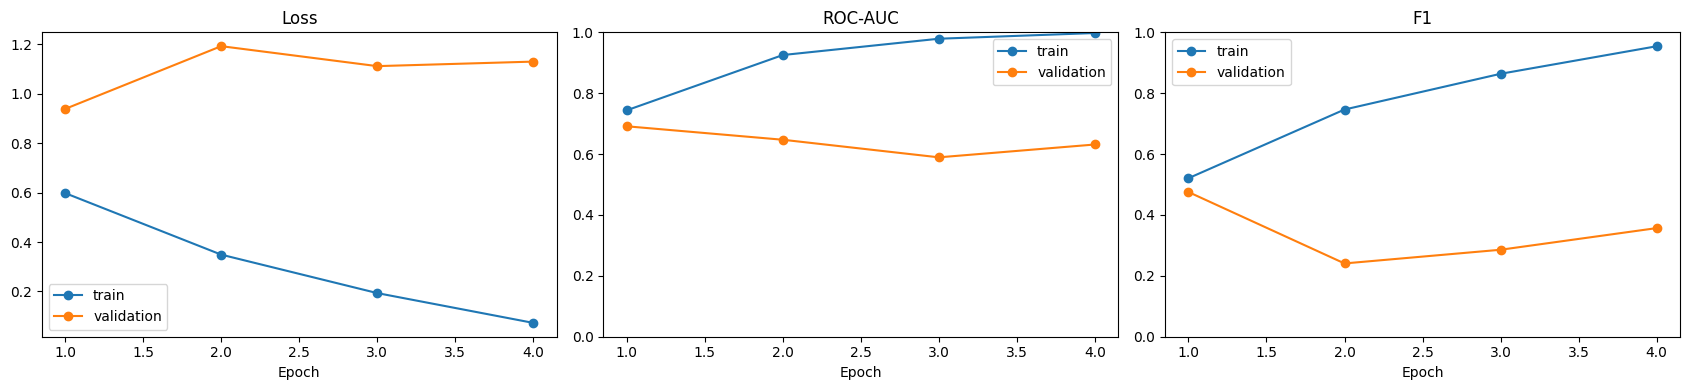


✅ 학습 완료
Best epoch: 1
Best validation score: 0.6913
Best model: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/03_best_resnet18.pt
History: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/04_training_history.csv
Learning curve: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/04_training_curves.png


In [ ]:
#@title 06. ResNet18 Prox LCX 2D classification 학습

import time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
)

from torchvision import models
from torchvision.models import ResNet18_Weights


# --------------------------------------------------
# Model 생성
# --------------------------------------------------

model = models.resnet18(
    weights=ResNet18_Weights.DEFAULT
)

model.fc = nn.Linear(
    model.fc.in_features,
    2,
)

model = model.to(DEVICE)


# --------------------------------------------------
# Class imbalance 보정
# --------------------------------------------------

train_class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

class_weights = []

for label in [0, 1]:

    class_count = int(
        train_class_counts.get(
            label,
            1,
        )
    )

    class_weight = (
        len(train_df)
        / (2.0 * class_count)
    )

    class_weights.append(
        class_weight
    )


class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE,
)

print("Train frame class counts:")
print(train_class_counts)

print("\nClass weights:")
print(class_weights)


# --------------------------------------------------
# Loss, optimizer, scheduler
# --------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1,
    )
)


# --------------------------------------------------
# Epoch 실행 함수
# --------------------------------------------------

def run_epoch(
    model,
    loader,
    training,
):

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0

    all_labels = []
    all_probabilities = []
    all_predictions = []

    for batch in loader:

        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        labels = batch["label"].to(
            DEVICE,
            non_blocking=True,
        )

        if training:
            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(
            training
        ):

            logits = model(images)

            loss = criterion(
                logits,
                labels,
            )

            if training:
                loss.backward()
                optimizer.step()

        probabilities = torch.softmax(
            logits,
            dim=1,
        )[:, 1]

        predictions = (
            probabilities >= 0.5
        ).long()

        total_loss += (
            loss.item()
            * images.size(0)
        )

        all_labels.extend(
            labels
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        all_probabilities.extend(
            probabilities
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        all_predictions.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )


    average_loss = (
        total_loss
        / len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions,
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0,
    )

    if len(set(all_labels)) == 2:
        auc = roc_auc_score(
            all_labels,
            all_probabilities,
        )
    else:
        auc = float("nan")

    return {
        "loss": float(
            average_loss
        ),
        "accuracy": float(
            accuracy
        ),
        "f1": float(
            f1
        ),
        "auc": float(
            auc
        ),
    }


# --------------------------------------------------
# Training
# --------------------------------------------------

history = []

best_validation_score = -np.inf
best_epoch = 0
epochs_without_improvement = 0


for epoch in range(
    1,
    NUM_EPOCHS + 1,
):

    epoch_start_time = time.time()

    train_metrics = run_epoch(
        model,
        train_loader,
        training=True,
    )

    validation_metrics = run_epoch(
        model,
        validation_loader,
        training=False,
    )

    validation_auc = (
        validation_metrics["auc"]
    )

    if np.isnan(validation_auc):
        current_validation_score = (
            validation_metrics["accuracy"]
        )
    else:
        current_validation_score = (
            validation_auc
        )

    scheduler.step(
        current_validation_score
    )

    epoch_seconds = (
        time.time()
        - epoch_start_time
    )

    epoch_record = {
        "epoch": epoch,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "train_auc": train_metrics["auc"],

        "validation_loss": validation_metrics["loss"],
        "validation_accuracy": validation_metrics["accuracy"],
        "validation_f1": validation_metrics["f1"],
        "validation_auc": validation_metrics["auc"],

        "learning_rate": optimizer.param_groups[0]["lr"],
        "seconds": epoch_seconds,
    }

    history.append(
        epoch_record
    )


    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train loss={train_metrics['loss']:.4f}, "
        f"acc={train_metrics['accuracy']:.4f}, "
        f"f1={train_metrics['f1']:.4f}, "
        f"auc={train_metrics['auc']:.4f} | "
        f"val loss={validation_metrics['loss']:.4f}, "
        f"acc={validation_metrics['accuracy']:.4f}, "
        f"f1={validation_metrics['f1']:.4f}, "
        f"auc={validation_metrics['auc']:.4f} | "
        f"{epoch_seconds:.1f}s"
    )


    # --------------------------------------------------
    # Best checkpoint 저장
    # --------------------------------------------------

    if (
        current_validation_score
        > best_validation_score
    ):

        best_validation_score = (
            current_validation_score
        )

        best_epoch = epoch

        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": (
                    model.state_dict()
                ),

                "target_segment": (
                    TARGET_SEGMENT
                ),

                "class_names": (
                    CLASS_NAMES
                ),

                "image_size": (
                    IMAGE_SIZE
                ),

                "best_validation_score": (
                    best_validation_score
                ),

                "best_epoch": (
                    best_epoch
                ),

                "seed": SEED,
            },
            BEST_MODEL_PATH,
        )

        print(
            "  ✅ Best model 저장:",
            BEST_MODEL_PATH,
        )

    else:
        epochs_without_improvement += 1


    # --------------------------------------------------
    # Early stopping
    # --------------------------------------------------

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f"\nEarly stopping: "
            f"{EARLY_STOPPING_PATIENCE}회 연속 개선 없음"
        )
        break


# --------------------------------------------------
# 학습 기록 저장
# --------------------------------------------------

history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    HISTORY_PATH,
    index=False,
    encoding="utf-8-sig",
)


# --------------------------------------------------
# Learning curve 시각화
# --------------------------------------------------

figure, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4),
)

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="train",
)

axes[0].plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="validation",
)

axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()


axes[1].plot(
    history_df["epoch"],
    history_df["train_auc"],
    marker="o",
    label="train",
)

axes[1].plot(
    history_df["epoch"],
    history_df["validation_auc"],
    marker="o",
    label="validation",
)

axes[1].set_title("ROC-AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[1].legend()


axes[2].plot(
    history_df["epoch"],
    history_df["train_f1"],
    marker="o",
    label="train",
)

axes[2].plot(
    history_df["epoch"],
    history_df["validation_f1"],
    marker="o",
    label="validation",
)

axes[2].set_title("F1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1)
axes[2].legend()


plt.tight_layout()

learning_curve_path = (
    PHASE1_OUTPUT_DIR
    / "04_training_curves.png"
)

plt.savefig(
    learning_curve_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print("\n✅ 학습 완료")
print("Best epoch:", best_epoch)
print("Best validation score:", round(best_validation_score, 4))
print("Best model:", BEST_MODEL_PATH)
print("History:", HISTORY_PATH)
print("Learning curve:", learning_curve_path)

=== Frame-level metrics ===
{
  "accuracy": 0.5307692307692308,
  "precision": 0.33268101761252444,
  "recall": 0.8717948717948718,
  "f1": 0.48158640226628896,
  "confusion_matrix": [
    [
      244,
      341
    ],
    [
      25,
      170
    ]
  ],
  "roc_auc": 0.7043348674117905
}

=== Patient-level metrics ===
{
  "accuracy": 0.5,
  "precision": 0.3409090909090909,
  "recall": 0.8823529411764706,
  "f1": 0.4918032786885246,
  "confusion_matrix": [
    [
      16,
      29
    ],
    [
      2,
      15
    ]
  ],
  "roc_auc": 0.7189542483660131
}

=== Patient-level classification report ===
              precision    recall  f1-score   support

          NL       0.89      0.36      0.51        45
    abnormal       0.34      0.88      0.49        17

    accuracy                           0.50        62
   macro avg       0.61      0.62      0.50        62
weighted avg       0.74      0.50      0.50        62



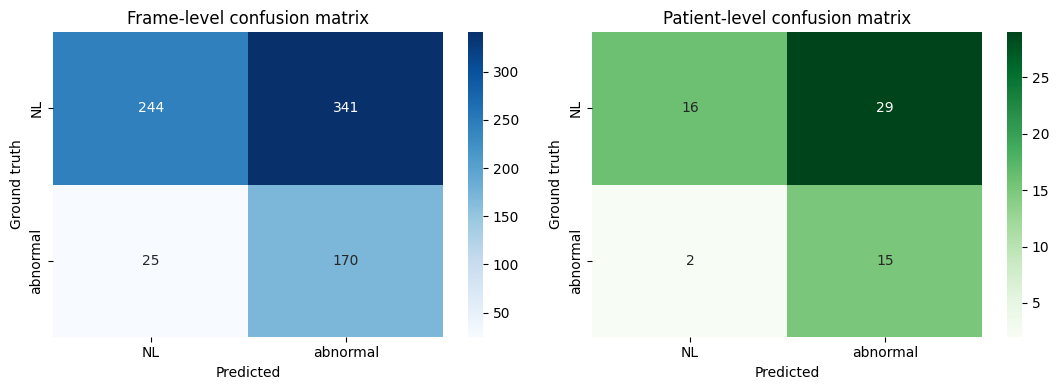


저장 완료:
Frame predictions: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/05_test_predictions.csv
Patient predictions: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/05_B_patient_predictions.csv
Metrics: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/06_test_metrics.json
Confusion matrices: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/07_confusion_matrices.png


In [ ]:
#@title 07. Test set frame-level 및 patient-level 평가

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)


# --------------------------------------------------
# Best checkpoint 불러오기
# --------------------------------------------------

try:
    checkpoint = torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE,
        weights_only=False,
    )
except TypeError:
    checkpoint = torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE,
    )


model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()


# --------------------------------------------------
# Test inference
# --------------------------------------------------

prediction_records = []


with torch.no_grad():

    for batch in test_loader:

        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        logits = model(images)

        probabilities = torch.softmax(
            logits,
            dim=1,
        )[:, 1]

        predictions = (
            probabilities >= 0.5
        ).long()

        current_batch_size = (
            images.size(0)
        )

        for index in range(
            current_batch_size
        ):

            prediction_records.append(
                {
                    "patient_id": int(
                        batch["patient_id"][
                            index
                        ]
                    ),

                    "series_id": int(
                        batch["series_id"][
                            index
                        ]
                    ),

                    "frame_path": str(
                        batch["frame_path"][
                            index
                        ]
                    ),

                    "label": int(
                        batch["label"][
                            index
                        ]
                    ),

                    "probability_abnormal": float(
                        probabilities[
                            index
                        ]
                        .detach()
                        .cpu()
                    ),

                    "prediction": int(
                        predictions[
                            index
                        ]
                        .detach()
                        .cpu()
                    ),
                }
            )


prediction_df = pd.DataFrame(
    prediction_records
)


# Excel grade 추가
test_grade_df = test_df[
    [
        "frame_path",
        "stenosis_grade",
    ]
].drop_duplicates(
    subset=["frame_path"]
)

prediction_df = prediction_df.merge(
    test_grade_df,
    on="frame_path",
    how="left",
)


prediction_df.to_csv(
    PREDICTION_PATH,
    index=False,
    encoding="utf-8-sig",
)


# --------------------------------------------------
# Metric 함수
# --------------------------------------------------

def calculate_binary_metrics(
    labels,
    probabilities,
    predictions,
):

    result = {
        "accuracy": float(
            accuracy_score(
                labels,
                predictions,
            )
        ),

        "precision": float(
            precision_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),

        "recall": float(
            recall_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),

        "f1": float(
            f1_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),

        "confusion_matrix": (
            confusion_matrix(
                labels,
                predictions,
            ).tolist()
        ),
    }

    if len(set(labels)) == 2:
        result["roc_auc"] = float(
            roc_auc_score(
                labels,
                probabilities,
            )
        )
    else:
        result["roc_auc"] = None

    return result


# --------------------------------------------------
# Frame-level metric
# --------------------------------------------------

frame_labels = (
    prediction_df["label"]
    .astype(int)
    .to_numpy()
)

frame_probabilities = (
    prediction_df[
        "probability_abnormal"
    ].to_numpy()
)

frame_predictions = (
    prediction_df["prediction"]
    .astype(int)
    .to_numpy()
)

frame_metrics = calculate_binary_metrics(
    frame_labels,
    frame_probabilities,
    frame_predictions,
)


# --------------------------------------------------
# Patient-level probability 평균
# --------------------------------------------------

patient_prediction_df = (
    prediction_df
    .groupby("patient_id")
    .agg(
        label=("label", "first"),
        probability_abnormal=(
            "probability_abnormal",
            "mean",
        ),
        frame_count=(
            "frame_path",
            "count",
        ),
    )
    .reset_index()
)

patient_prediction_df[
    "prediction"
] = (
    patient_prediction_df[
        "probability_abnormal"
    ] >= 0.5
).astype(int)


patient_prediction_path = (
    PHASE1_OUTPUT_DIR
    / "05_B_patient_predictions.csv"
)

patient_prediction_df.to_csv(
    patient_prediction_path,
    index=False,
    encoding="utf-8-sig",
)


patient_labels = (
    patient_prediction_df[
        "label"
    ]
    .astype(int)
    .to_numpy()
)

patient_probabilities = (
    patient_prediction_df[
        "probability_abnormal"
    ].to_numpy()
)

patient_predictions = (
    patient_prediction_df[
        "prediction"
    ]
    .astype(int)
    .to_numpy()
)

patient_metrics = calculate_binary_metrics(
    patient_labels,
    patient_probabilities,
    patient_predictions,
)


# --------------------------------------------------
# 전체 결과 저장
# --------------------------------------------------

all_metrics = {
    "target_segment": TARGET_SEGMENT,
    "decision_threshold": 0.5,
    "best_epoch": int(
        checkpoint["best_epoch"]
    ),
    "best_validation_score": float(
        checkpoint[
            "best_validation_score"
        ]
    ),
    "frame_level": frame_metrics,
    "patient_level": patient_metrics,
}


with open(
    METRICS_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        all_metrics,
        file,
        indent=2,
        ensure_ascii=False,
    )


print("=== Frame-level metrics ===")
print(
    json.dumps(
        frame_metrics,
        indent=2,
        ensure_ascii=False,
    )
)

print("\n=== Patient-level metrics ===")
print(
    json.dumps(
        patient_metrics,
        indent=2,
        ensure_ascii=False,
    )
)


print("\n=== Patient-level classification report ===")

print(
    classification_report(
        patient_labels,
        patient_predictions,
        target_names=[
            CLASS_NAMES[0],
            CLASS_NAMES[1],
        ],
        zero_division=0,
    )
)


# --------------------------------------------------
# Confusion matrix
# --------------------------------------------------

frame_confusion = confusion_matrix(
    frame_labels,
    frame_predictions,
)

patient_confusion = confusion_matrix(
    patient_labels,
    patient_predictions,
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4),
)


sns.heatmap(
    frame_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        CLASS_NAMES[0],
        CLASS_NAMES[1],
    ],
    yticklabels=[
        CLASS_NAMES[0],
        CLASS_NAMES[1],
    ],
    ax=axes[0],
)

axes[0].set_title(
    "Frame-level confusion matrix"
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Ground truth")


sns.heatmap(
    patient_confusion,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[
        CLASS_NAMES[0],
        CLASS_NAMES[1],
    ],
    yticklabels=[
        CLASS_NAMES[0],
        CLASS_NAMES[1],
    ],
    ax=axes[1],
)

axes[1].set_title(
    "Patient-level confusion matrix"
)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Ground truth")


plt.tight_layout()

confusion_path = (
    PHASE1_OUTPUT_DIR
    / "07_confusion_matrices.png"
)

plt.savefig(
    confusion_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print("\n저장 완료:")
print("Frame predictions:", PREDICTION_PATH)
print("Patient predictions:", patient_prediction_path)
print("Metrics:", METRICS_PATH)
print("Confusion matrices:", confusion_path)

Grad-CAM 생성 대상: 6 개


,patient_id,series_id,stenosis_grade,probability_abnormal,prediction,frame_path
0,108,4,1-25,0.999254,1,/content/AngioCAD_classification_data/AngioCAD...
1,112,9,76-90,0.996619,1,/content/AngioCAD_classification_data/AngioCAD...
2,60,3,76-90,0.993384,1,/content/AngioCAD_classification_data/AngioCAD...
3,45,3,26-50,0.986467,1,/content/AngioCAD_classification_data/AngioCAD...
4,110,4,76-90,0.985455,1,/content/AngioCAD_classification_data/AngioCAD...
5,392,1,1-25,0.984674,1,/content/AngioCAD_classification_data/AngioCAD...


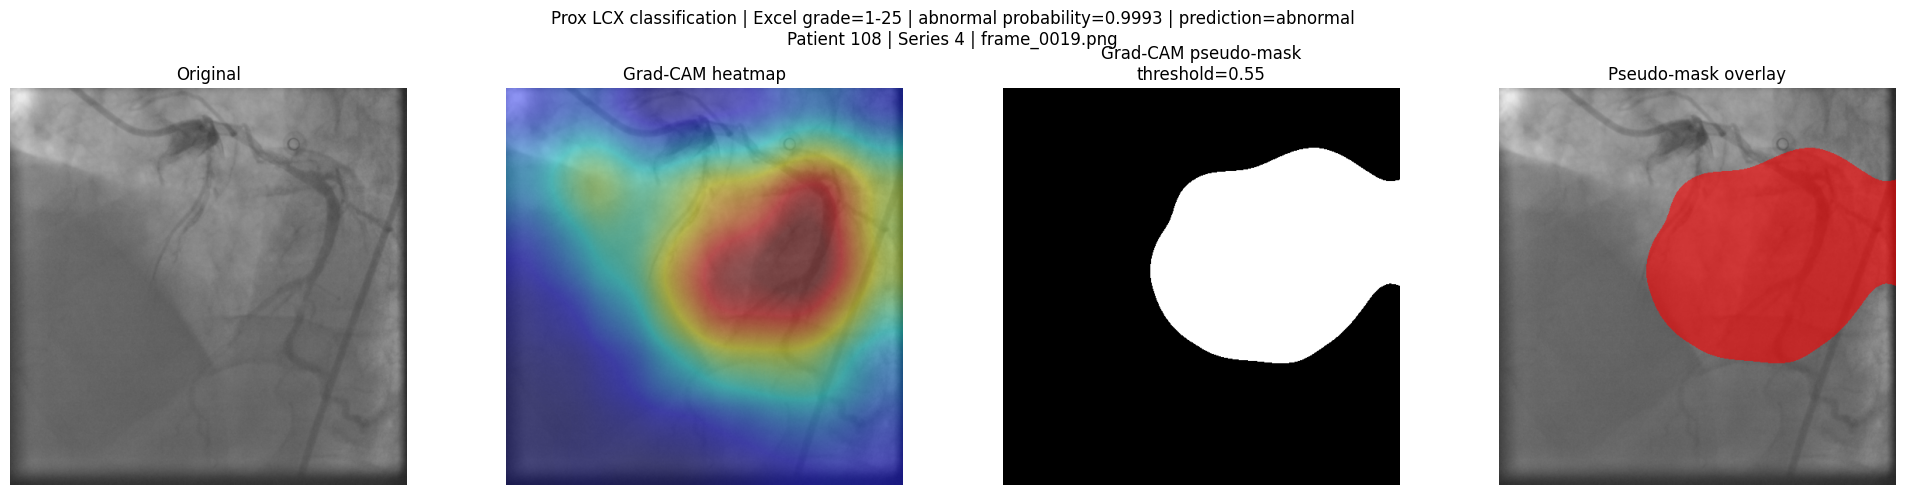

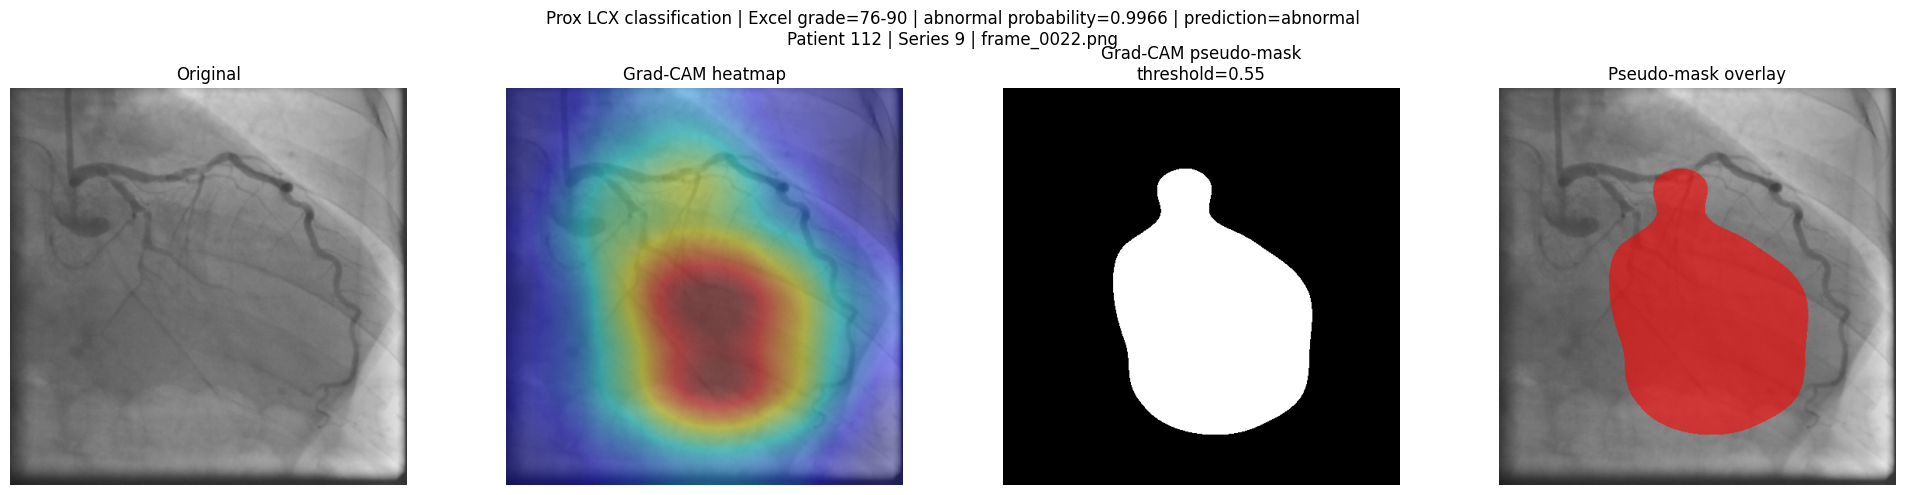

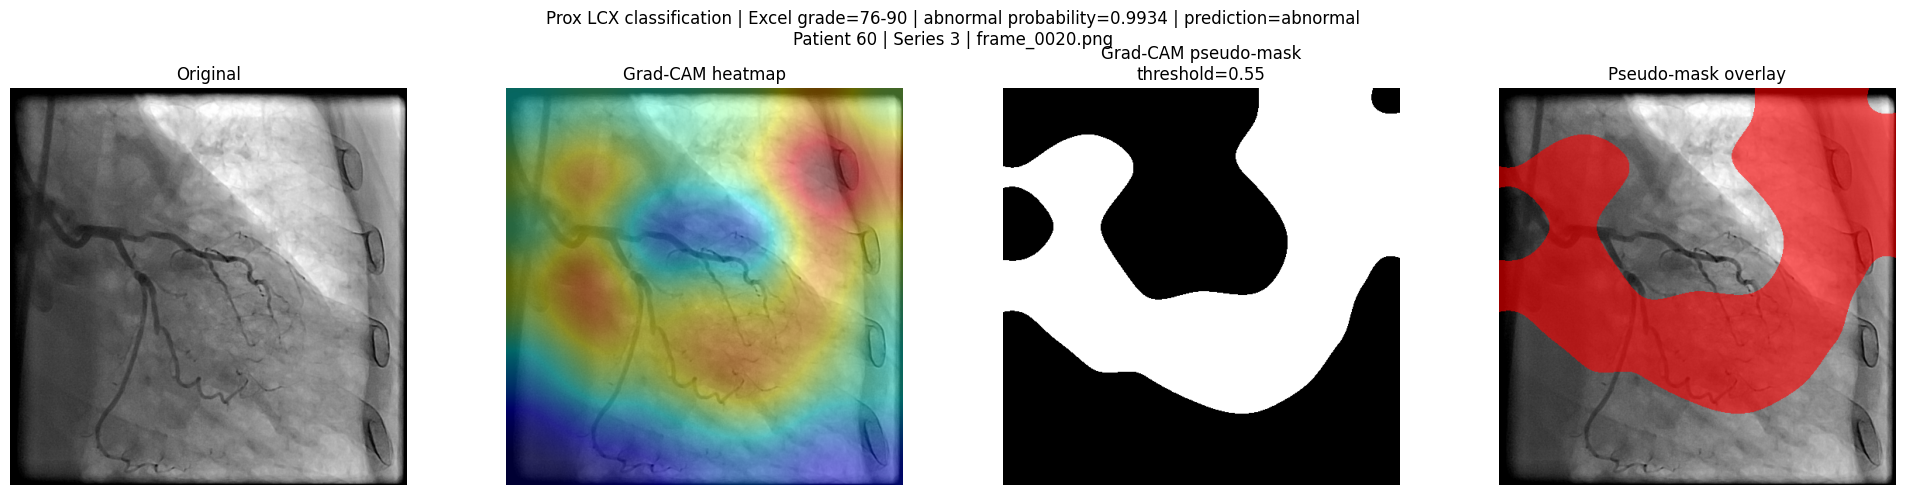

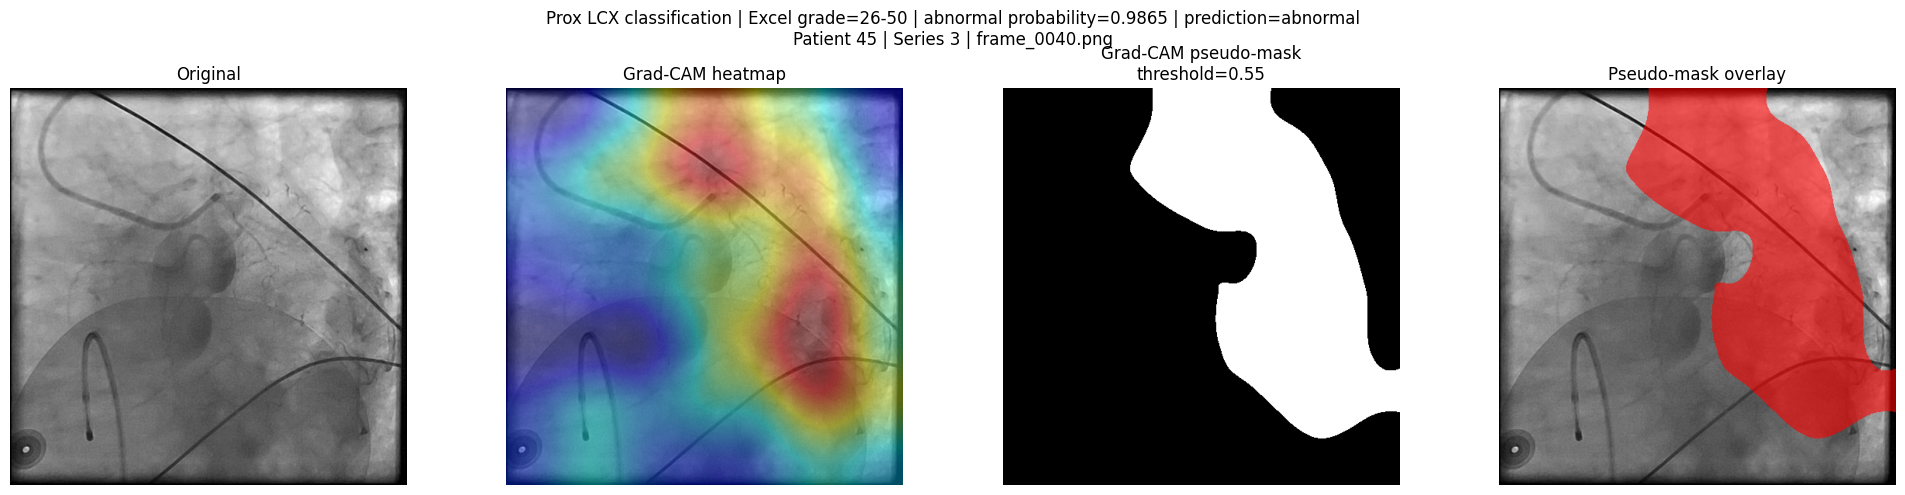

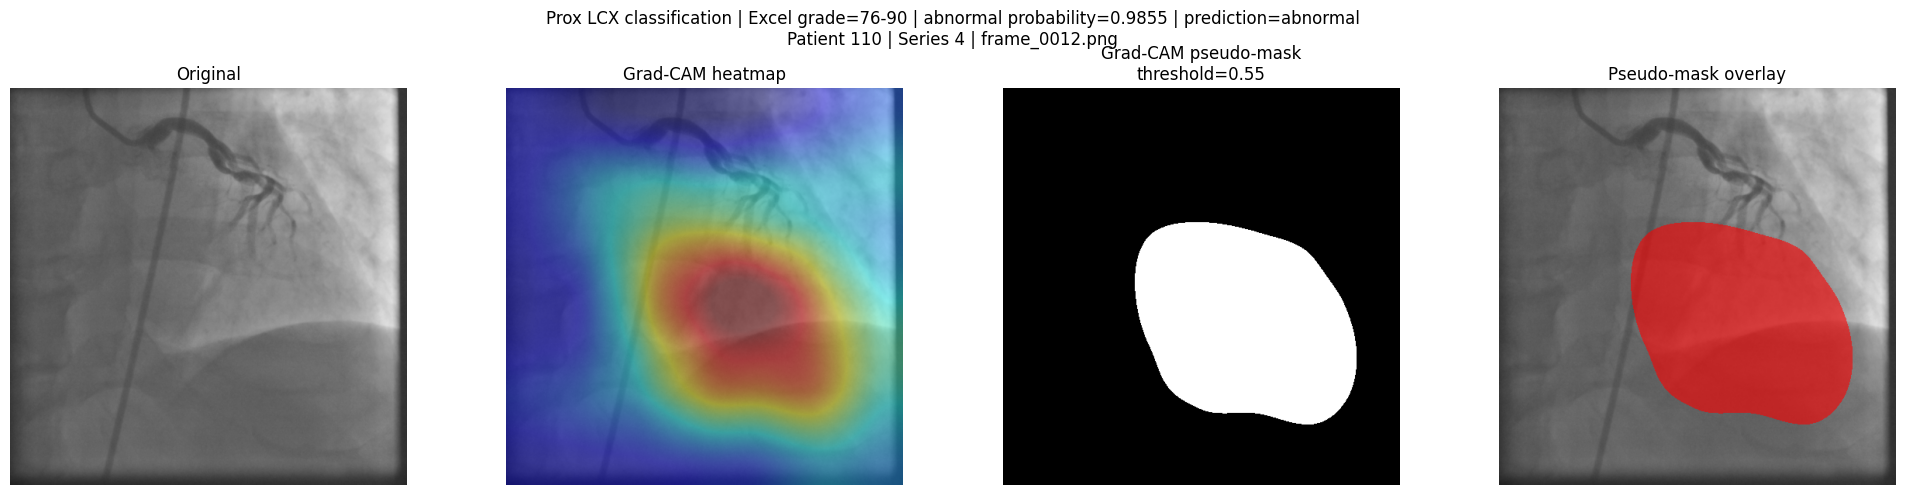

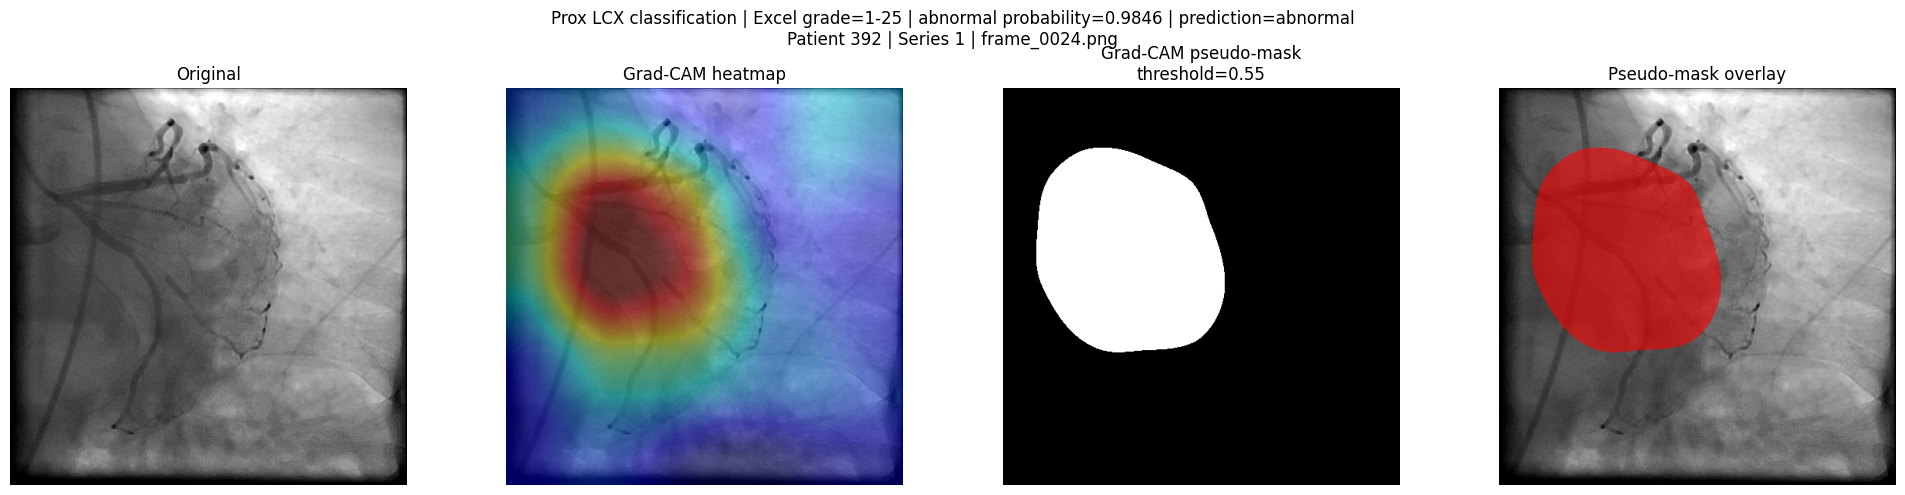


✅ 1단계 완료
Classification model: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/03_best_resnet18.pt
Classification metrics: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/06_test_metrics.json
Grad-CAM 결과 폴더: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/gradcam_results
Grad-CAM summary: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/08_gradcam_summary.csv


,patient_id,series_id,frame_path,target_segment,stenosis_grade,abnormal_probability,predicted_class,predicted_class_name,cam_threshold,mask_pixels,mask_area_ratio,raw_cam_path,heatmap_path,raw_mask_path,pseudo_mask_path,comparison_path
0,108,4,/content/AngioCAD_classification_data/AngioCAD...,Prox LCX,1-25,0.999252,1,abnormal,0.55,68134,0.259911,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...
1,112,9,/content/AngioCAD_classification_data/AngioCAD...,Prox LCX,76-90,0.996630,1,abnormal,0.55,61274,0.233742,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...
2,60,3,/content/AngioCAD_classification_data/AngioCAD...,Prox LCX,76-90,0.993401,1,abnormal,0.55,113156,0.431656,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...
3,45,3,/content/AngioCAD_classification_data/AngioCAD...,Prox LCX,26-50,0.986492,1,abnormal,0.55,81845,0.312214,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...
4,110,4,/content/AngioCAD_classification_data/AngioCAD...,Prox LCX,76-90,0.985510,1,abnormal,0.55,58481,0.223087,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...
5,392,1,/content/AngioCAD_classification_data/AngioCAD...,Prox LCX,1-25,0.984647,1,abnormal,0.55,51564,0.196701,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...


In [ ]:
#@title 08. Grad-CAM heatmap 및 독립적인 pseudo-mask 생성

import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image


# --------------------------------------------------
# Grad-CAM
# --------------------------------------------------

class GradCAM:

    def __init__(
        self,
        model,
        target_layer,
    ):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = (
            self.target_layer
            .register_forward_hook(
                self._forward_hook
            )
        )

    def _save_gradient(
        self,
        gradient,
    ):
        self.gradients = (
            gradient.detach()
        )

    def _forward_hook(
        self,
        module,
        inputs,
        output,
    ):
        self.activations = (
            output.detach()
        )

        output.register_hook(
            self._save_gradient
        )

    def generate(
        self,
        input_tensor,
        target_class=1,
    ):
        self.model.eval()

        self.model.zero_grad(
            set_to_none=True
        )

        logits = self.model(
            input_tensor
        )

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        target_probability = float(
            probabilities[
                0,
                target_class,
            ]
            .detach()
            .cpu()
        )

        predicted_class = int(
            probabilities.argmax(
                dim=1
            )[0]
            .detach()
            .cpu()
        )

        target_logit = logits[
            0,
            target_class,
        ]

        target_logit.backward()

        assert self.activations is not None, (
            "Activation을 얻지 못했습니다."
        )

        assert self.gradients is not None, (
            "Gradient를 얻지 못했습니다."
        )

        weights = self.gradients.mean(
            dim=(2, 3),
            keepdim=True,
        )

        cam = (
            weights
            * self.activations
        ).sum(
            dim=1,
        )

        cam = torch.relu(
            cam
        )

        cam = (
            cam[0]
            .detach()
            .cpu()
            .numpy()
        )

        cam = cam - cam.min()

        if cam.max() > 0:
            cam = cam / cam.max()

        return (
            cam,
            target_probability,
            predicted_class,
        )

    def close(self):
        self.forward_handle.remove()


# --------------------------------------------------
# 작은 component 제거
# --------------------------------------------------

def remove_small_components(
    binary_mask,
    minimum_area,
):

    number_of_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            binary_mask.astype(
                np.uint8
            ),
            connectivity=8,
        )
    )

    cleaned_mask = np.zeros_like(
        binary_mask,
        dtype=np.uint8,
    )

    for component_id in range(
        1,
        number_of_labels,
    ):

        component_area = stats[
            component_id,
            cv2.CC_STAT_AREA,
        ]

        if component_area >= minimum_area:

            cleaned_mask[
                labels == component_id
            ] = 1

    return cleaned_mask


# --------------------------------------------------
# CAM → binary pseudo-mask
# --------------------------------------------------

def cam_to_binary_mask(
    cam,
    output_width,
    output_height,
):

    resized_cam = cv2.resize(
        cam,
        (
            output_width,
            output_height,
        ),
        interpolation=cv2.INTER_CUBIC,
    )

    resized_cam = np.clip(
        resized_cam,
        0,
        1,
    )

    raw_binary_mask = (
        resized_cam
        >= CAM_THRESHOLD
    ).astype(np.uint8)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (7, 7),
    )

    cleaned_mask = cv2.morphologyEx(
        raw_binary_mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2,
    )

    cleaned_mask = cv2.morphologyEx(
        cleaned_mask,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1,
    )

    minimum_area = max(
        10,
        int(
            output_width
            * output_height
            * MIN_COMPONENT_AREA_RATIO
        ),
    )

    cleaned_mask = remove_small_components(
        cleaned_mask,
        minimum_area,
    )

    return (
        resized_cam,
        raw_binary_mask,
        cleaned_mask,
    )


# --------------------------------------------------
# 환자별 대표 abnormal frame 선택
# --------------------------------------------------

positive_test_df = (
    prediction_df[
        prediction_df["label"] == 1
    ]
    .sort_values(
        "probability_abnormal",
        ascending=False,
    )
    .drop_duplicates(
        subset=["patient_id"]
    )
    .head(NUM_CAM_EXAMPLES)
    .reset_index(drop=True)
)

assert len(positive_test_df) > 0, (
    "Test set에 abnormal sample이 없습니다."
)

print(
    "Grad-CAM 생성 대상:",
    len(positive_test_df),
    "개"
)

display(
    positive_test_df[
        [
            "patient_id",
            "series_id",
            "stenosis_grade",
            "probability_abnormal",
            "prediction",
            "frame_path",
        ]
    ]
)


# --------------------------------------------------
# Grad-CAM 생성
# --------------------------------------------------

gradcam = GradCAM(
    model=model,
    target_layer=model.layer4[-1],
)

gradcam_summary = []


for sample_index, row in (
    positive_test_df.iterrows()
):

    image_path = Path(
        row["frame_path"]
    )

    original_image = Image.open(
        image_path
    ).convert("RGB")

    original_rgb = np.array(
        original_image
    )

    original_height, original_width = (
        original_rgb.shape[:2]
    )


    input_tensor = (
        evaluation_transform(
            original_image
        )
        .unsqueeze(0)
        .to(DEVICE)
    )


    (
        raw_cam,
        abnormal_probability,
        predicted_class,
    ) = gradcam.generate(
        input_tensor,
        target_class=1,
    )


    (
        resized_cam,
        raw_binary_mask,
        cleaned_binary_mask,
    ) = cam_to_binary_mask(
        raw_cam,
        output_width=original_width,
        output_height=original_height,
    )


    # --------------------------------------------------
    # Heatmap overlay
    # --------------------------------------------------

    heatmap_uint8 = (
        resized_cam * 255
    ).astype(np.uint8)

    heatmap_bgr = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET,
    )

    heatmap_rgb = cv2.cvtColor(
        heatmap_bgr,
        cv2.COLOR_BGR2RGB,
    )

    heatmap_overlay = cv2.addWeighted(
        original_rgb,
        0.60,
        heatmap_rgb,
        0.40,
        0,
    )


    # --------------------------------------------------
    # Pseudo-mask overlay
    # --------------------------------------------------

    pseudo_mask_overlay = (
        original_rgb.copy()
    )

    mask_boolean = (
        cleaned_binary_mask.astype(
            bool
        )
    )

    red_color = np.zeros_like(
        original_rgb
    )

    red_color[:, :, 0] = 255

    pseudo_mask_overlay[
        mask_boolean
    ] = (
        0.40
        * pseudo_mask_overlay[
            mask_boolean
        ]
        + 0.60
        * red_color[
            mask_boolean
        ]
    ).astype(np.uint8)


    # --------------------------------------------------
    # 저장 파일명
    # --------------------------------------------------

    sample_name = (
        f"patient_{int(row['patient_id']):03d}"
        f"_series_{int(row['series_id']):02d}"
        f"_{image_path.stem}"
    )

    raw_cam_npy_path = (
        GRADCAM_OUTPUT_DIR
        / f"{sample_name}_gradcam.npy"
    )

    heatmap_png_path = (
        GRADCAM_OUTPUT_DIR
        / f"{sample_name}_heatmap.png"
    )

    raw_mask_path = (
        GRADCAM_OUTPUT_DIR
        / f"{sample_name}_raw_mask.png"
    )

    cleaned_mask_path = (
        GRADCAM_OUTPUT_DIR
        / f"{sample_name}_pseudo_mask.png"
    )

    comparison_path = (
        GRADCAM_OUTPUT_DIR
        / f"{sample_name}_comparison.png"
    )


    np.save(
        raw_cam_npy_path,
        resized_cam.astype(
            np.float32
        ),
    )

    Image.fromarray(
        heatmap_uint8
    ).save(
        heatmap_png_path
    )

    Image.fromarray(
        raw_binary_mask * 255
    ).save(
        raw_mask_path
    )

    Image.fromarray(
        cleaned_binary_mask * 255
    ).save(
        cleaned_mask_path
    )


    # --------------------------------------------------
    # 비교 그림
    # --------------------------------------------------

    figure, axes = plt.subplots(
        1,
        4,
        figsize=(20, 5),
    )


    axes[0].imshow(
        original_rgb
    )
    axes[0].set_title(
        "Original"
    )


    axes[1].imshow(
        heatmap_overlay
    )
    axes[1].set_title(
        "Grad-CAM heatmap"
    )


    axes[2].imshow(
        cleaned_binary_mask,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[2].set_title(
        "Grad-CAM pseudo-mask\n"
        f"threshold={CAM_THRESHOLD}"
    )


    axes[3].imshow(
        pseudo_mask_overlay
    )
    axes[3].set_title(
        "Pseudo-mask overlay"
    )


    for axis in axes:
        axis.axis("off")


    figure.suptitle(
        f"{TARGET_SEGMENT} classification | "
        f"Excel grade={row['stenosis_grade']} | "
        f"abnormal probability={abnormal_probability:.4f} | "
        f"prediction={CLASS_NAMES[predicted_class]}\n"
        f"Patient {int(row['patient_id'])} | "
        f"Series {int(row['series_id'])} | "
        f"{image_path.name}",
        fontsize=12,
    )


    plt.tight_layout()

    plt.savefig(
        comparison_path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)


    mask_pixels = int(
        cleaned_binary_mask.sum()
    )

    mask_area_ratio = float(
        cleaned_binary_mask.mean()
    )


    gradcam_summary.append(
        {
            "patient_id": int(
                row["patient_id"]
            ),

            "series_id": int(
                row["series_id"]
            ),

            "frame_path": str(
                image_path
            ),

            "target_segment": (
                TARGET_SEGMENT
            ),

            "stenosis_grade": str(
                row["stenosis_grade"]
            ),

            "abnormal_probability": float(
                abnormal_probability
            ),

            "predicted_class": int(
                predicted_class
            ),

            "predicted_class_name": (
                CLASS_NAMES[
                    predicted_class
                ]
            ),

            "cam_threshold": float(
                CAM_THRESHOLD
            ),

            "mask_pixels": (
                mask_pixels
            ),

            "mask_area_ratio": (
                mask_area_ratio
            ),

            "raw_cam_path": str(
                raw_cam_npy_path
            ),

            "heatmap_path": str(
                heatmap_png_path
            ),

            "raw_mask_path": str(
                raw_mask_path
            ),

            "pseudo_mask_path": str(
                cleaned_mask_path
            ),

            "comparison_path": str(
                comparison_path
            ),
        }
    )


gradcam.close()


# --------------------------------------------------
# Grad-CAM 요약 저장
# --------------------------------------------------

gradcam_summary_df = pd.DataFrame(
    gradcam_summary
)

gradcam_summary_path = (
    PHASE1_OUTPUT_DIR
    / "08_gradcam_summary.csv"
)

gradcam_summary_df.to_csv(
    gradcam_summary_path,
    index=False,
    encoding="utf-8-sig",
)


print("\n✅ 1단계 완료")
print("Classification model:", BEST_MODEL_PATH)
print("Classification metrics:", METRICS_PATH)
print("Grad-CAM 결과 폴더:", GRADCAM_OUTPUT_DIR)
print("Grad-CAM summary:", gradcam_summary_path)

display(
    gradcam_summary_df
)

In [ ]:
#@title 09. 전체 혈관 segment별 NL/abnormal 환자 수 확인

ALL_SEGMENTS = [
    "LM",
    "Prox LAD",
    "Mid LAD",
    "Dist LAD",
    "1st dig",
    "2nd dig",
    "Prox LCX",
    "Mid LCX",
    "Dist LCX",
    "OM",
    "Prox RCA",
    "Mid RCA",
    "Dist RCA",
    "PDA",
    "PLB",
]

segment_distribution_records = []

for segment in ALL_SEGMENTS:

    normalized_labels = (
        labels_df[segment]
        .apply(normalize_grade)
    )

    abnormal_flags = (
        normalized_labels != "NL"
    )

    nl_count = int(
        (~abnormal_flags).sum()
    )

    abnormal_count = int(
        abnormal_flags.sum()
    )

    valid_count = (
        nl_count
        + abnormal_count
    )

    abnormal_ratio = (
        abnormal_count / valid_count
        if valid_count > 0
        else 0
    )

    segment_distribution_records.append(
        {
            "segment": segment,
            "side": (
                "left"
                if segment in LEFT_SEGMENTS
                else "right"
            ),
            "NL_patients": nl_count,
            "abnormal_patients": abnormal_count,
            "abnormal_ratio": abnormal_ratio,
            "total_patients": valid_count,
        }
    )


segment_distribution_df = pd.DataFrame(
    segment_distribution_records
).sort_values(
    [
        "side",
        "abnormal_patients",
    ],
    ascending=[
        True,
        False,
    ],
)


distribution_path = (
    HYUNKYUNG_ROOT
    / "01_classification_gradcam"
    / "segment_label_distribution.csv"
)

segment_distribution_df.to_csv(
    distribution_path,
    index=False,
    encoding="utf-8-sig",
)


display(
    segment_distribution_df.style.format(
        {
            "abnormal_ratio": "{:.3f}",
        }
    )
)

print("저장:", distribution_path)

,segment,side,NL_patients,abnormal_patients,abnormal_ratio,total_patients
2,Mid LAD,left,148,265,0.642,413
1,Prox LAD,left,252,161,0.390,413
9,OM,left,257,156,0.378,413
4,1st dig,left,274,139,0.337,413
6,Prox LCX,left,301,112,0.271,413
7,Mid LCX,left,327,86,0.208,413
5,2nd dig,left,368,45,0.109,413
3,Dist LAD,left,379,34,0.082,413
0,LM,left,383,30,0.073,413
8,Dist LCX,left,386,27,0.065,413


저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/segment_label_distribution.csv


In [ ]:
#@title 10. 새 혈관 실험 설정 - Prox LAD

import re
import json
from pathlib import Path


# --------------------------------------------------
# 새로운 실험 대상
# --------------------------------------------------

TARGET_SEGMENT = "Prox LAD"

CLASS_NAMES = {
    0: "NL",
    1: "abnormal",
}

TARGET_SLUG = re.sub(
    r"[^a-zA-Z0-9]+",
    "_",
    TARGET_SEGMENT.strip().lower(),
).strip("_")


# --------------------------------------------------
# 혈관별 독립 저장 폴더
# --------------------------------------------------

PHASE1_BASE_DIR = (
    HYUNKYUNG_ROOT
    / "01_classification_gradcam"
)

PHASE1_OUTPUT_DIR = (
    PHASE1_BASE_DIR
    / TARGET_SLUG
)

GRADCAM_OUTPUT_DIR = (
    PHASE1_OUTPUT_DIR
    / "gradcam_results"
)

PHASE1_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

GRADCAM_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------
# 저장 경로 재설정
# --------------------------------------------------

DATA_INDEX_PATH = (
    PHASE1_OUTPUT_DIR
    / "01_frame_index.csv"
)

SPLIT_INDEX_PATH = (
    PHASE1_OUTPUT_DIR
    / "02_split_index.csv"
)

BEST_MODEL_PATH = (
    PHASE1_OUTPUT_DIR
    / "03_best_resnet18.pt"
)

HISTORY_PATH = (
    PHASE1_OUTPUT_DIR
    / "04_training_history.csv"
)

PREDICTION_PATH = (
    PHASE1_OUTPUT_DIR
    / "05_test_predictions.csv"
)

METRICS_PATH = (
    PHASE1_OUTPUT_DIR
    / "06_test_metrics.json"
)


# --------------------------------------------------
# 설정 저장
# --------------------------------------------------

config = {
    "target_segment": TARGET_SEGMENT,
    "class_names": CLASS_NAMES,
    "image_size": IMAGE_SIZE,
    "frames_per_series": FRAMES_PER_SERIES,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "cam_threshold": CAM_THRESHOLD,
    "seed": SEED,
}

with open(
    PHASE1_OUTPUT_DIR / "00_config.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        config,
        file,
        indent=2,
        ensure_ascii=False,
    )


print("새로운 target:", TARGET_SEGMENT)
print("새로운 결과 폴더:", PHASE1_OUTPUT_DIR)
print(json.dumps(config, indent=2, ensure_ascii=False))

새로운 target: Prox LAD
새로운 결과 폴더: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad
{
  "target_segment": "Prox LAD",
  "class_names": {
    "0": "NL",
    "1": "abnormal"
  },
  "image_size": 224,
  "frames_per_series": 3,
  "batch_size": 32,
  "num_epochs": 10,
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "cam_threshold": 0.55,
  "seed": 42
}


In [ ]:
#@title 11. Prox LAD classification 실험 설정

import os
import re
import json
import random
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)


ImageFile.LOAD_TRUNCATED_IMAGES = True


# --------------------------------------------------
# 기존 셀 실행 여부 확인
# --------------------------------------------------

assert "HYUNKYUNG_ROOT" in globals(), (
    "먼저 셀 00의 Drive 및 저장 경로 설정을 실행하세요."
)

assert "DATASET_ROOT" in globals(), (
    "먼저 셀 03의 RAR 압축 해제를 실행하세요."
)

assert "LABEL_FILE" in globals(), (
    "Excel label 경로를 찾지 못했습니다."
)


if "labels_df" not in globals():
    labels_df = pd.read_excel(
        LABEL_FILE,
        sheet_name="Labels",
    )

    labels_df.columns = [
        str(column).strip()
        for column in labels_df.columns
    ]


# --------------------------------------------------
# 재현성
# --------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )


# --------------------------------------------------
# Prox LAD 실험 설정
# --------------------------------------------------

TARGET_SEGMENT = "Prox LAD"
TARGET_SIDE = "left"
SERIES_COLUMN = "Left Coronary Series"

CLASS_NAMES = {
    0: "NL",
    1: "abnormal",
}

IMAGE_SIZE = 224
FRAMES_PER_SERIES = 3

BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 3

CAM_THRESHOLD = 0.55
MIN_COMPONENT_AREA_RATIO = 0.001
NUM_CAM_EXAMPLES = 6

NUM_WORKERS = 2


# --------------------------------------------------
# LAD 전용 저장 폴더
# --------------------------------------------------

PHASE1_BASE_DIR = (
    HYUNKYUNG_ROOT
    / "01_classification_gradcam"
)

PHASE1_OUTPUT_DIR = (
    PHASE1_BASE_DIR
    / "prox_lad"
)

GRADCAM_OUTPUT_DIR = (
    PHASE1_OUTPUT_DIR
    / "gradcam_results"
)

PHASE1_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

GRADCAM_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------
# 저장 파일 경로
# --------------------------------------------------

DATA_INDEX_PATH = (
    PHASE1_OUTPUT_DIR
    / "01_frame_index.csv"
)

SPLIT_INDEX_PATH = (
    PHASE1_OUTPUT_DIR
    / "02_split_index.csv"
)

MISSING_SERIES_PATH = (
    PHASE1_OUTPUT_DIR
    / "02_A_missing_series.csv"
)

OMITTED_PATIENT_PATH = (
    PHASE1_OUTPUT_DIR
    / "02_B_omitted_patients.csv"
)

BEST_MODEL_PATH = (
    PHASE1_OUTPUT_DIR
    / "03_best_resnet18.pt"
)

HISTORY_PATH = (
    PHASE1_OUTPUT_DIR
    / "04_training_history.csv"
)

TRAINING_CURVE_PATH = (
    PHASE1_OUTPUT_DIR
    / "04_training_curves.png"
)

PREDICTION_PATH = (
    PHASE1_OUTPUT_DIR
    / "05_test_predictions.csv"
)

PATIENT_PREDICTION_PATH = (
    PHASE1_OUTPUT_DIR
    / "05_B_patient_predictions.csv"
)

METRICS_PATH = (
    PHASE1_OUTPUT_DIR
    / "06_test_metrics.json"
)

CONFUSION_PATH = (
    PHASE1_OUTPUT_DIR
    / "07_confusion_matrices.png"
)

GRADCAM_SUMMARY_PATH = (
    PHASE1_OUTPUT_DIR
    / "08_gradcam_summary.csv"
)


# 기존 LCX에서 만든 patient split
LCX_SPLIT_PATH = (
    PHASE1_BASE_DIR
    / "02_split_index.csv"
)


config = {
    "target_segment": TARGET_SEGMENT,
    "target_side": TARGET_SIDE,
    "series_column": SERIES_COLUMN,
    "class_names": CLASS_NAMES,
    "image_size": IMAGE_SIZE,
    "frames_per_series": FRAMES_PER_SERIES,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "cam_threshold": CAM_THRESHOLD,
    "seed": SEED,
    "reuse_lcx_patient_split": (
        LCX_SPLIT_PATH.exists()
    ),
}


with open(
    PHASE1_OUTPUT_DIR / "00_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        config,
        file,
        indent=2,
        ensure_ascii=False,
    )


print("\n새로운 target:", TARGET_SEGMENT)
print("새로운 결과 폴더:", PHASE1_OUTPUT_DIR)
print("LCX split 존재:", LCX_SPLIT_PATH.exists())

print(
    json.dumps(
        config,
        indent=2,
        ensure_ascii=False,
    )
)

Device: cuda
GPU: NVIDIA L4

새로운 target: Prox LAD
새로운 결과 폴더: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad
LCX split 존재: True
{
  "target_segment": "Prox LAD",
  "target_side": "left",
  "series_column": "Left Coronary Series",
  "class_names": {
    "0": "NL",
    "1": "abnormal"
  },
  "image_size": 224,
  "frames_per_series": 3,
  "batch_size": 32,
  "num_epochs": 10,
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "early_stopping_patience": 3,
  "cam_threshold": 0.55,
  "seed": 42,
  "reuse_lcx_patient_split": true
}


In [ ]:
#@title 12. Prox LAD frame index 및 patient-level split 생성

LEFT_SEGMENTS = [
    "LM",
    "Prox LAD",
    "Mid LAD",
    "Dist LAD",
    "1st dig",
    "2nd dig",
    "Prox LCX",
    "Mid LCX",
    "Dist LCX",
    "OM",
]

RIGHT_SEGMENTS = [
    "Prox RCA",
    "Mid RCA",
    "Dist RCA",
    "PDA",
    "PLB",
]


# --------------------------------------------------
# 보조 함수
# --------------------------------------------------

def normalize_grade(value):

    if pd.isna(value):
        return "NL"

    value = str(value).strip().upper()

    value = value.replace("–", "-")
    value = value.replace("—", "-")
    value = value.replace(" ", "")

    if value in {
        "",
        "NL",
        "NORMAL",
        "NOLESION",
        "NONE",
        "NAN",
    }:
        return "NL"

    if value.endswith(".0"):
        value = value[:-2]

    return value


def is_abnormal_grade(value):

    return (
        normalize_grade(value)
        != "NL"
    )


def parse_series_spec(value):

    if pd.isna(value):
        return []

    if isinstance(
        value,
        (int, np.integer),
    ):
        return [int(value)]

    if isinstance(value, float):
        return [int(value)]

    text = str(value)

    text = text.replace("–", "-")
    text = text.replace("—", "-")

    tokens = re.findall(
        r"\d+\s*-\s*\d+|\d+",
        text,
    )

    series_ids = []

    for token in tokens:

        if "-" in token:

            start_value, end_value = [
                int(number.strip())
                for number
                in token.split("-")
            ]

            # 8-3처럼 역방향인 값은
            # 의미를 임의로 추정하지 않고 제외
            if start_value > end_value:
                continue

            series_ids.extend(
                range(
                    start_value,
                    end_value + 1,
                )
            )

        else:
            series_ids.append(
                int(token)
            )

    return sorted(
        set(series_ids)
    )


def frame_sort_key(path):

    numbers = re.findall(
        r"\d+",
        path.stem,
    )

    if len(numbers) == 0:
        return 0

    return int(
        numbers[-1]
    )


def select_representative_frames(
    frame_paths,
    number_of_frames,
):

    frame_paths = sorted(
        frame_paths,
        key=frame_sort_key,
    )

    total = len(frame_paths)

    if total <= number_of_frames:
        return frame_paths

    relative_positions = np.linspace(
        0.30,
        0.70,
        number_of_frames,
    )

    selected_indices = sorted(
        set(
            int(
                round(
                    position
                    * (total - 1)
                )
            )
            for position
            in relative_positions
        )
    )

    return [
        frame_paths[index]
        for index
        in selected_indices
    ]


# --------------------------------------------------
# Excel 확인
# --------------------------------------------------

required_columns = {
    "ID",
    SERIES_COLUMN,
    TARGET_SEGMENT,
}

missing_columns = (
    required_columns
    - set(labels_df.columns)
)

assert not missing_columns, (
    f"Excel에 필요한 열이 없습니다: {missing_columns}"
)


# --------------------------------------------------
# 환자 폴더 mapping
# --------------------------------------------------

patient_directory_map = {}

for directory in DATASET_ROOT.iterdir():

    if (
        directory.is_dir()
        and directory.name.isdigit()
    ):
        patient_directory_map[
            int(directory.name)
        ] = directory


# --------------------------------------------------
# Frame index 생성
# --------------------------------------------------

records = []
missing_patients = []
missing_series = []
invalid_series_specs = []

valid_extensions = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
}


for _, row in labels_df.iterrows():

    try:
        patient_id = int(
            row["ID"]
        )
    except Exception:
        continue

    patient_directory = (
        patient_directory_map.get(
            patient_id
        )
    )

    if patient_directory is None:

        missing_patients.append(
            patient_id
        )

        continue


    grade = normalize_grade(
        row[TARGET_SEGMENT]
    )

    binary_label = int(
        is_abnormal_grade(
            grade
        )
    )


    raw_series_spec = row[
        SERIES_COLUMN
    ]

    series_ids = parse_series_spec(
        raw_series_spec
    )

    if (
        len(series_ids) == 0
        and not pd.isna(
            raw_series_spec
        )
    ):
        invalid_series_specs.append(
            {
                "patient_id": patient_id,
                "raw_series_spec": str(
                    raw_series_spec
                ),
            }
        )


    for series_id in series_ids:

        possible_series_names = [
            str(series_id),
            f"{series_id:02d}",
            f"{series_id:03d}",
        ]

        series_directory = None

        for series_name in (
            possible_series_names
        ):
            candidate = (
                patient_directory
                / series_name
            )

            if candidate.exists():
                series_directory = (
                    candidate
                )
                break


        if series_directory is None:

            missing_series.append(
                (
                    patient_id,
                    series_id,
                )
            )

            continue


        frame_paths = [
            path
            for path
            in series_directory.iterdir()
            if (
                path.is_file()
                and path.suffix.lower()
                in valid_extensions
            )
        ]


        selected_frames = (
            select_representative_frames(
                frame_paths,
                FRAMES_PER_SERIES,
            )
        )


        for frame_path in selected_frames:

            records.append(
                {
                    "patient_id": (
                        patient_id
                    ),

                    "series_id": (
                        series_id
                    ),

                    "frame_name": (
                        frame_path.name
                    ),

                    "frame_path": str(
                        frame_path
                    ),

                    "target_segment": (
                        TARGET_SEGMENT
                    ),

                    "stenosis_grade": (
                        grade
                    ),

                    "label": (
                        binary_label
                    ),

                    "class_name": (
                        CLASS_NAMES[
                            binary_label
                        ]
                    ),
                }
            )


frame_df = pd.DataFrame(
    records
)

assert len(frame_df) > 0, (
    "Prox LAD frame index가 비어 있습니다."
)


frame_df.to_csv(
    DATA_INDEX_PATH,
    index=False,
    encoding="utf-8-sig",
)


# --------------------------------------------------
# LCX와 동일한 patient split 재사용
# --------------------------------------------------

if LCX_SPLIT_PATH.exists():

    lcx_split_df = pd.read_csv(
        LCX_SPLIT_PATH
    )

    patient_split_map = (
        lcx_split_df[
            [
                "patient_id",
                "split",
            ]
        ]
        .drop_duplicates(
            subset=["patient_id"]
        )
        .set_index("patient_id")[
            "split"
        ]
        .to_dict()
    )

    frame_df["split"] = (
        frame_df["patient_id"]
        .map(patient_split_map)
    )

    # LCX 실험에서 제외된 환자는
    # LAD 비교에서도 동일하게 제외
    frame_df = frame_df[
        frame_df["split"].notna()
    ].copy()

    print(
        "✅ LCX와 동일한 patient split을 사용합니다."
    )

else:

    print(
        "⚠️ LCX split을 찾지 못해 "
        "Prox LAD용 split을 새로 생성합니다."
    )

    patient_label_df = (
        frame_df[
            [
                "patient_id",
                "label",
            ]
        ]
        .drop_duplicates()
        .sort_values(
            "patient_id"
        )
        .reset_index(
            drop=True
        )
    )

    patient_ids = (
        patient_label_df[
            "patient_id"
        ].to_numpy()
    )

    patient_labels = (
        patient_label_df[
            "label"
        ].to_numpy()
    )

    (
        train_patient_ids,
        temporary_patient_ids,
    ) = train_test_split(
        patient_ids,
        test_size=0.30,
        random_state=SEED,
        stratify=patient_labels,
    )

    temporary_labels = (
        patient_label_df
        .set_index("patient_id")
        .loc[
            temporary_patient_ids,
            "label",
        ]
        .to_numpy()
    )

    (
        validation_patient_ids,
        test_patient_ids,
    ) = train_test_split(
        temporary_patient_ids,
        test_size=0.50,
        random_state=SEED,
        stratify=temporary_labels,
    )

    train_patient_set = set(
        train_patient_ids
    )

    validation_patient_set = set(
        validation_patient_ids
    )

    test_patient_set = set(
        test_patient_ids
    )

    def assign_split(
        patient_id
    ):

        if patient_id in train_patient_set:
            return "train"

        if patient_id in validation_patient_set:
            return "validation"

        if patient_id in test_patient_set:
            return "test"

        return None

    frame_df["split"] = (
        frame_df["patient_id"]
        .apply(assign_split)
    )


# --------------------------------------------------
# Index 저장
# --------------------------------------------------

frame_df.to_csv(
    SPLIT_INDEX_PATH,
    index=False,
    encoding="utf-8-sig",
)


# --------------------------------------------------
# 누락 자료 저장
# --------------------------------------------------

missing_series_df = pd.DataFrame(
    sorted(
        set(missing_series)
    ),
    columns=[
        "patient_id",
        "series_id",
    ],
)

missing_series_df[
    "target_segment"
] = TARGET_SEGMENT

missing_series_df[
    "expected_side"
] = TARGET_SIDE

missing_series_df.to_csv(
    MISSING_SERIES_PATH,
    index=False,
    encoding="utf-8-sig",
)


excel_patient_ids = set(
    pd.to_numeric(
        labels_df["ID"],
        errors="coerce",
    )
    .dropna()
    .astype(int)
    .tolist()
)

indexed_patient_ids = set(
    frame_df["patient_id"]
    .astype(int)
    .unique()
    .tolist()
)

omitted_patient_ids = sorted(
    excel_patient_ids
    - indexed_patient_ids
)


omitted_patient_df = (
    labels_df[
        pd.to_numeric(
            labels_df["ID"],
            errors="coerce",
        ).isin(
            omitted_patient_ids
        )
    ][
        [
            "ID",
            SERIES_COLUMN,
            TARGET_SEGMENT,
        ]
    ]
    .copy()
)

omitted_patient_df.to_csv(
    OMITTED_PATIENT_PATH,
    index=False,
    encoding="utf-8-sig",
)


# --------------------------------------------------
# 분포 확인
# --------------------------------------------------

patient_split_df = (
    frame_df[
        [
            "patient_id",
            "label",
            "class_name",
            "split",
        ]
    ]
    .drop_duplicates(
        subset=["patient_id"]
    )
)


print("\n=== Prox LAD 환자 단위 split 분포 ===")

display(
    pd.crosstab(
        patient_split_df[
            "split"
        ],
        patient_split_df[
            "class_name"
        ],
    )
)


print("\n=== Prox LAD frame 단위 split 분포 ===")

display(
    pd.crosstab(
        frame_df["split"],
        frame_df["class_name"],
    )
)


print("\n전체 frame 수:", len(frame_df))
print("전체 환자 수:", frame_df["patient_id"].nunique())
print("누락 환자 수:", len(omitted_patient_ids))
print("누락 series 수:", len(missing_series_df))

print("\nIndex 저장:", SPLIT_INDEX_PATH)
print("누락 series 저장:", MISSING_SERIES_PATH)
print("제외 환자 저장:", OMITTED_PATIENT_PATH)

if len(invalid_series_specs) > 0:

    print("\n=== 비정상 series 표기 ===")

    display(
        pd.DataFrame(
            invalid_series_specs
        )
    )

display(
    frame_df.head()
)

✅ LCX와 동일한 patient split을 사용합니다.

=== Prox LAD 환자 단위 split 분포 ===


class_name,NL,abnormal
split,,
test,38,24
train,173,114
validation,41,20



=== Prox LAD frame 단위 split 분포 ===


class_name,NL,abnormal
split,,
test,492,288
train,2374,1595
validation,594,273



전체 frame 수: 5616
전체 환자 수: 410
누락 환자 수: 3
누락 series 수: 9

Index 저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/02_split_index.csv
누락 series 저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/02_A_missing_series.csv
제외 환자 저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/02_B_omitted_patients.csv

=== 비정상 series 표기 ===


,patient_id,raw_series_spec
0,353,8-3


,patient_id,series_id,frame_name,frame_path,target_segment,stenosis_grade,label,class_name,split
0,1,3,frame_0021.png,/content/AngioCAD_classification_data/AngioCAD...,Prox LAD,100,1,abnormal,train
1,1,3,frame_0034.png,/content/AngioCAD_classification_data/AngioCAD...,Prox LAD,100,1,abnormal,train
2,1,3,frame_0048.png,/content/AngioCAD_classification_data/AngioCAD...,Prox LAD,100,1,abnormal,train
3,1,4,frame_0014.png,/content/AngioCAD_classification_data/AngioCAD...,Prox LAD,100,1,abnormal,train
4,1,4,frame_0024.png,/content/AngioCAD_classification_data/AngioCAD...,Prox LAD,100,1,abnormal,train


In [ ]:
#@title 13. Prox LAD Dataset 및 DataLoader 생성

train_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),

        transforms.RandomRotation(
            degrees=5
        ),

        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.15,
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[
                0.485,
                0.456,
                0.406,
            ],
            std=[
                0.229,
                0.224,
                0.225,
            ],
        ),
    ]
)


evaluation_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[
                0.485,
                0.456,
                0.406,
            ],
            std=[
                0.229,
                0.224,
                0.225,
            ],
        ),
    ]
)


class AngioFrameDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform,
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform

    def __len__(self):

        return len(
            self.dataframe
        )

    def __getitem__(
        self,
        index,
    ):

        row = (
            self.dataframe
            .iloc[index]
        )

        image = Image.open(
            row["frame_path"]
        ).convert("RGB")

        image_tensor = (
            self.transform(
                image
            )
        )

        label = int(
            row["label"]
        )

        return {
            "image": image_tensor,

            "label": torch.tensor(
                label,
                dtype=torch.long,
            ),

            "patient_id": int(
                row["patient_id"]
            ),

            "series_id": int(
                row["series_id"]
            ),

            "frame_path": str(
                row["frame_path"]
            ),
        }


train_df = frame_df[
    frame_df["split"]
    == "train"
].copy()

validation_df = frame_df[
    frame_df["split"]
    == "validation"
].copy()

test_df = frame_df[
    frame_df["split"]
    == "test"
].copy()


train_dataset = AngioFrameDataset(
    train_df,
    train_transform,
)

validation_dataset = AngioFrameDataset(
    validation_df,
    evaluation_transform,
)

test_dataset = AngioFrameDataset(
    test_df,
    evaluation_transform,
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


print("=== Prox LAD Dataset ===")
print("Train frames:", len(train_dataset))
print("Validation frames:", len(validation_dataset))
print("Test frames:", len(test_dataset))


sample_batch = next(
    iter(train_loader)
)

print(
    "Batch image shape:",
    sample_batch["image"].shape,
)

print(
    "Batch label shape:",
    sample_batch["label"].shape,
)

print(
    "Batch labels:",
    sample_batch[
        "label"
    ][:10].tolist(),
)

=== Prox LAD Dataset ===
Train frames: 3969
Validation frames: 867
Test frames: 780
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Batch labels: [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]


Train frame class counts:
label
0    2374
1    1595
Name: count, dtype: int64

Class weights:
tensor([0.8359, 1.2442], device='cuda:0')
Epoch 01/10 | train loss=0.6265, acc=0.6405, f1=0.5956, auc=0.7029 | val loss=0.7719, acc=0.4983, f1=0.4402, auc=0.5740 | 19.6s
  ✅ Best model 저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/03_best_resnet18.pt
Epoch 02/10 | train loss=0.4092, acc=0.8075, f1=0.7741, auc=0.8951 | val loss=0.9896, acc=0.5248, f1=0.4246, auc=0.5297 | 19.5s
Epoch 03/10 | train loss=0.2155, acc=0.9151, f1=0.8973, auc=0.9730 | val loss=1.1571, acc=0.5502, f1=0.4730, auc=0.5946 | 19.5s
  ✅ Best model 저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/03_best_resnet18.pt
Epoch 04/10 | train loss=0.1406, acc=0.9463, f1=0.9341, auc=0.9884 | val loss=1.2402, acc=0.5744, f1=0.4152, auc=0.5867 | 19.4s
Epoch 05/10 | train loss=0.0759, acc=0.9728, f1=0.9666

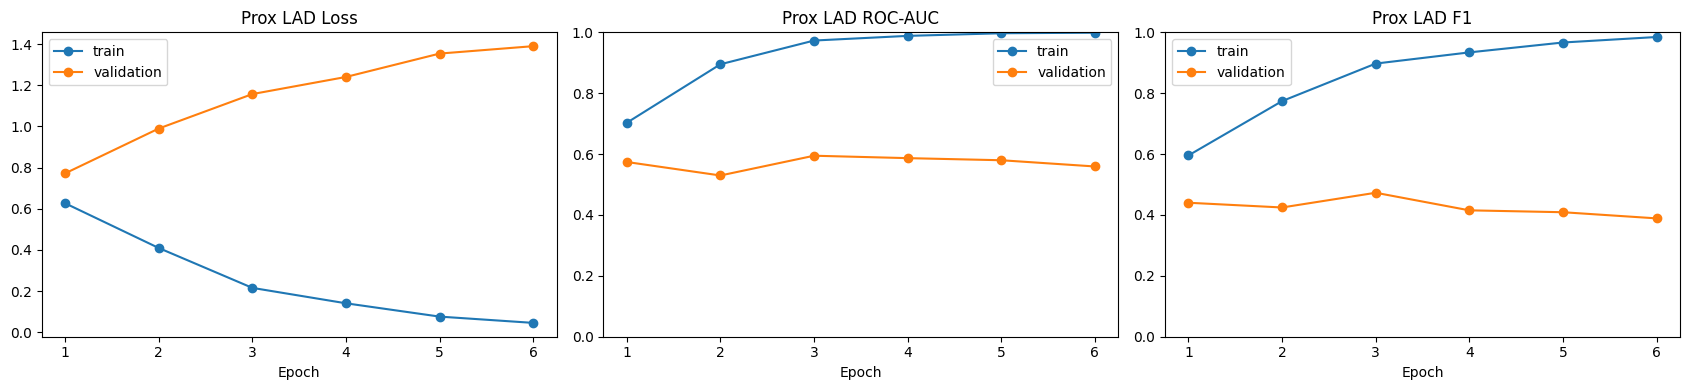


✅ Prox LAD 학습 완료
Best epoch: 3
Best validation score: 0.5946
Best model: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/03_best_resnet18.pt
History: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/04_training_history.csv
Learning curve: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/04_training_curves.png


In [ ]:
#@title 14. Prox LAD ResNet18 2D classification 학습

model = models.resnet18(
    weights=ResNet18_Weights.DEFAULT
)

model.fc = nn.Linear(
    model.fc.in_features,
    2,
)

model = model.to(
    DEVICE
)


# --------------------------------------------------
# Class weight
# --------------------------------------------------

train_class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

class_weights = []

for label in [0, 1]:

    class_count = int(
        train_class_counts.get(
            label,
            1,
        )
    )

    class_weight = (
        len(train_df)
        / (2.0 * class_count)
    )

    class_weights.append(
        class_weight
    )


class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE,
)


print("Train frame class counts:")
print(train_class_counts)

print("\nClass weights:")
print(class_weights)


criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1,
    )
)


def run_epoch(
    model,
    loader,
    training,
):

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0

    all_labels = []
    all_probabilities = []
    all_predictions = []


    for batch in loader:

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        labels = batch[
            "label"
        ].to(
            DEVICE,
            non_blocking=True,
        )


        if training:
            optimizer.zero_grad(
                set_to_none=True
            )


        with torch.set_grad_enabled(
            training
        ):

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels,
            )

            if training:
                loss.backward()
                optimizer.step()


        probabilities = torch.softmax(
            logits,
            dim=1,
        )[:, 1]

        predictions = (
            probabilities
            >= 0.5
        ).long()


        total_loss += (
            loss.item()
            * images.size(0)
        )

        all_labels.extend(
            labels
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        all_probabilities.extend(
            probabilities
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        all_predictions.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )


    average_loss = (
        total_loss
        / len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions,
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0,
    )

    if len(set(all_labels)) == 2:

        auc = roc_auc_score(
            all_labels,
            all_probabilities,
        )

    else:
        auc = float("nan")


    return {
        "loss": float(
            average_loss
        ),

        "accuracy": float(
            accuracy
        ),

        "f1": float(
            f1
        ),

        "auc": float(
            auc
        ),
    }


# --------------------------------------------------
# Training
# --------------------------------------------------

history = []

best_validation_score = -np.inf
best_epoch = 0

epochs_without_improvement = 0


for epoch in range(
    1,
    NUM_EPOCHS + 1,
):

    epoch_start_time = (
        time.time()
    )


    train_metrics = run_epoch(
        model,
        train_loader,
        training=True,
    )

    validation_metrics = run_epoch(
        model,
        validation_loader,
        training=False,
    )


    validation_auc = (
        validation_metrics[
            "auc"
        ]
    )

    if np.isnan(
        validation_auc
    ):
        current_validation_score = (
            validation_metrics[
                "accuracy"
            ]
        )
    else:
        current_validation_score = (
            validation_auc
        )


    scheduler.step(
        current_validation_score
    )


    epoch_seconds = (
        time.time()
        - epoch_start_time
    )


    epoch_record = {
        "epoch": epoch,

        "train_loss": (
            train_metrics["loss"]
        ),

        "train_accuracy": (
            train_metrics[
                "accuracy"
            ]
        ),

        "train_f1": (
            train_metrics["f1"]
        ),

        "train_auc": (
            train_metrics["auc"]
        ),

        "validation_loss": (
            validation_metrics[
                "loss"
            ]
        ),

        "validation_accuracy": (
            validation_metrics[
                "accuracy"
            ]
        ),

        "validation_f1": (
            validation_metrics[
                "f1"
            ]
        ),

        "validation_auc": (
            validation_metrics[
                "auc"
            ]
        ),

        "learning_rate": (
            optimizer
            .param_groups[0][
                "lr"
            ]
        ),

        "seconds": (
            epoch_seconds
        ),
    }


    history.append(
        epoch_record
    )


    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train loss={train_metrics['loss']:.4f}, "
        f"acc={train_metrics['accuracy']:.4f}, "
        f"f1={train_metrics['f1']:.4f}, "
        f"auc={train_metrics['auc']:.4f} | "
        f"val loss={validation_metrics['loss']:.4f}, "
        f"acc={validation_metrics['accuracy']:.4f}, "
        f"f1={validation_metrics['f1']:.4f}, "
        f"auc={validation_metrics['auc']:.4f} | "
        f"{epoch_seconds:.1f}s"
    )


    if (
        current_validation_score
        > best_validation_score
    ):

        best_validation_score = (
            current_validation_score
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        torch.save(
            {
                "model_state_dict": (
                    model.state_dict()
                ),

                "target_segment": (
                    TARGET_SEGMENT
                ),

                "class_names": (
                    CLASS_NAMES
                ),

                "image_size": (
                    IMAGE_SIZE
                ),

                "best_validation_score": (
                    best_validation_score
                ),

                "best_epoch": (
                    best_epoch
                ),

                "seed": (
                    SEED
                ),
            },
            BEST_MODEL_PATH,
        )


        print(
            "  ✅ Best model 저장:",
            BEST_MODEL_PATH,
        )

    else:

        epochs_without_improvement += 1


    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping:",
            f"{EARLY_STOPPING_PATIENCE}회 연속 개선 없음",
        )

        break


# --------------------------------------------------
# History 저장
# --------------------------------------------------

history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    HISTORY_PATH,
    index=False,
    encoding="utf-8-sig",
)


# --------------------------------------------------
# Learning curve
# --------------------------------------------------

figure, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4),
)


axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="train",
)

axes[0].plot(
    history_df["epoch"],
    history_df[
        "validation_loss"
    ],
    marker="o",
    label="validation",
)

axes[0].set_title(
    "Prox LAD Loss"
)

axes[0].set_xlabel(
    "Epoch"
)

axes[0].legend()


axes[1].plot(
    history_df["epoch"],
    history_df["train_auc"],
    marker="o",
    label="train",
)

axes[1].plot(
    history_df["epoch"],
    history_df[
        "validation_auc"
    ],
    marker="o",
    label="validation",
)

axes[1].set_title(
    "Prox LAD ROC-AUC"
)

axes[1].set_xlabel(
    "Epoch"
)

axes[1].set_ylim(
    0,
    1,
)

axes[1].legend()


axes[2].plot(
    history_df["epoch"],
    history_df["train_f1"],
    marker="o",
    label="train",
)

axes[2].plot(
    history_df["epoch"],
    history_df[
        "validation_f1"
    ],
    marker="o",
    label="validation",
)

axes[2].set_title(
    "Prox LAD F1"
)

axes[2].set_xlabel(
    "Epoch"
)

axes[2].set_ylim(
    0,
    1,
)

axes[2].legend()


plt.tight_layout()

plt.savefig(
    TRAINING_CURVE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print("\n✅ Prox LAD 학습 완료")
print("Best epoch:", best_epoch)
print(
    "Best validation score:",
    round(
        best_validation_score,
        4,
    ),
)

print("Best model:", BEST_MODEL_PATH)
print("History:", HISTORY_PATH)
print("Learning curve:", TRAINING_CURVE_PATH)

=== Prox LAD Frame-level metrics ===
{
  "accuracy": 0.5551282051282052,
  "precision": 0.42377260981912146,
  "recall": 0.5694444444444444,
  "f1": 0.48592592592592593,
  "confusion_matrix": [
    [
      269,
      223
    ],
    [
      124,
      164
    ]
  ],
  "roc_auc": 0.5832557023486902
}

=== Prox LAD Patient-level metrics ===
{
  "accuracy": 0.5967741935483871,
  "precision": 0.4838709677419355,
  "recall": 0.625,
  "f1": 0.5454545454545454,
  "confusion_matrix": [
    [
      22,
      16
    ],
    [
      9,
      15
    ]
  ],
  "roc_auc": 0.6392543859649122
}

=== Patient-level classification report ===
              precision    recall  f1-score   support

          NL       0.71      0.58      0.64        38
    abnormal       0.48      0.62      0.55        24

    accuracy                           0.60        62
   macro avg       0.60      0.60      0.59        62
weighted avg       0.62      0.60      0.60        62



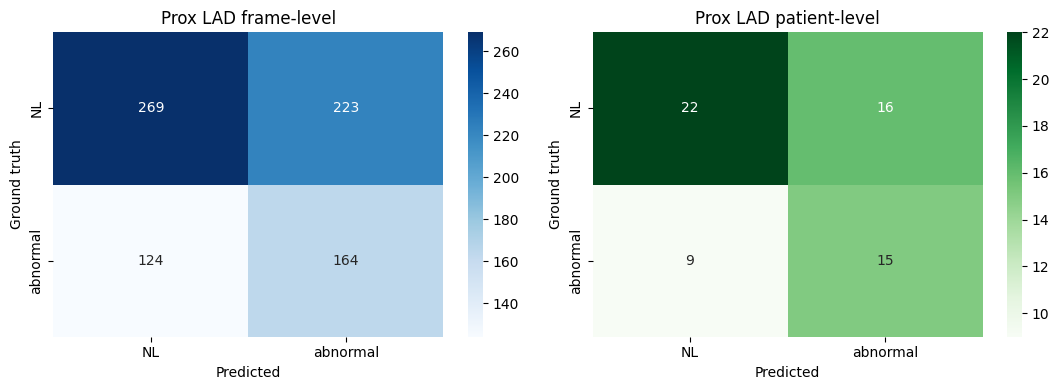


저장 완료:
Frame predictions: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/05_test_predictions.csv
Patient predictions: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/05_B_patient_predictions.csv
Metrics: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/06_test_metrics.json
Confusion matrices: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/07_confusion_matrices.png


In [ ]:
#@title 15. Prox LAD frame-level 및 patient-level 평가

try:
    checkpoint = torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE,
        weights_only=False,
    )

except TypeError:
    checkpoint = torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE,
    )


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model.eval()


prediction_records = []


with torch.no_grad():

    for batch in test_loader:

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        logits = model(
            images
        )

        probabilities = torch.softmax(
            logits,
            dim=1,
        )[:, 1]

        predictions = (
            probabilities
            >= 0.5
        ).long()


        for index in range(
            images.size(0)
        ):

            prediction_records.append(
                {
                    "patient_id": int(
                        batch[
                            "patient_id"
                        ][index]
                    ),

                    "series_id": int(
                        batch[
                            "series_id"
                        ][index]
                    ),

                    "frame_path": str(
                        batch[
                            "frame_path"
                        ][index]
                    ),

                    "label": int(
                        batch[
                            "label"
                        ][index]
                    ),

                    "probability_abnormal": float(
                        probabilities[
                            index
                        ]
                        .detach()
                        .cpu()
                    ),

                    "prediction": int(
                        predictions[
                            index
                        ]
                        .detach()
                        .cpu()
                    ),
                }
            )


prediction_df = pd.DataFrame(
    prediction_records
)


test_grade_df = test_df[
    [
        "frame_path",
        "stenosis_grade",
    ]
].drop_duplicates(
    subset=["frame_path"]
)


prediction_df = (
    prediction_df.merge(
        test_grade_df,
        on="frame_path",
        how="left",
    )
)


prediction_df.to_csv(
    PREDICTION_PATH,
    index=False,
    encoding="utf-8-sig",
)


def calculate_binary_metrics(
    labels,
    probabilities,
    predictions,
):

    result = {
        "accuracy": float(
            accuracy_score(
                labels,
                predictions,
            )
        ),

        "precision": float(
            precision_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),

        "recall": float(
            recall_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),

        "f1": float(
            f1_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),

        "confusion_matrix": (
            confusion_matrix(
                labels,
                predictions,
            ).tolist()
        ),
    }

    if len(set(labels)) == 2:

        result["roc_auc"] = float(
            roc_auc_score(
                labels,
                probabilities,
            )
        )

    else:
        result["roc_auc"] = None

    return result


# --------------------------------------------------
# Frame-level
# --------------------------------------------------

frame_labels = (
    prediction_df["label"]
    .astype(int)
    .to_numpy()
)

frame_probabilities = (
    prediction_df[
        "probability_abnormal"
    ].to_numpy()
)

frame_predictions = (
    prediction_df[
        "prediction"
    ]
    .astype(int)
    .to_numpy()
)


frame_metrics = (
    calculate_binary_metrics(
        frame_labels,
        frame_probabilities,
        frame_predictions,
    )
)


# --------------------------------------------------
# Patient-level
# --------------------------------------------------

patient_prediction_df = (
    prediction_df
    .groupby("patient_id")
    .agg(
        label=(
            "label",
            "first",
        ),

        probability_abnormal=(
            "probability_abnormal",
            "mean",
        ),

        frame_count=(
            "frame_path",
            "count",
        ),
    )
    .reset_index()
)


patient_prediction_df[
    "prediction"
] = (
    patient_prediction_df[
        "probability_abnormal"
    ] >= 0.5
).astype(int)


patient_prediction_df.to_csv(
    PATIENT_PREDICTION_PATH,
    index=False,
    encoding="utf-8-sig",
)


patient_labels = (
    patient_prediction_df[
        "label"
    ]
    .astype(int)
    .to_numpy()
)

patient_probabilities = (
    patient_prediction_df[
        "probability_abnormal"
    ].to_numpy()
)

patient_predictions = (
    patient_prediction_df[
        "prediction"
    ]
    .astype(int)
    .to_numpy()
)


patient_metrics = (
    calculate_binary_metrics(
        patient_labels,
        patient_probabilities,
        patient_predictions,
    )
)


all_metrics = {
    "target_segment": (
        TARGET_SEGMENT
    ),

    "decision_threshold": 0.5,

    "best_epoch": int(
        checkpoint[
            "best_epoch"
        ]
    ),

    "best_validation_score": float(
        checkpoint[
            "best_validation_score"
        ]
    ),

    "frame_level": (
        frame_metrics
    ),

    "patient_level": (
        patient_metrics
    ),
}


with open(
    METRICS_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        all_metrics,
        file,
        indent=2,
        ensure_ascii=False,
    )


print("=== Prox LAD Frame-level metrics ===")

print(
    json.dumps(
        frame_metrics,
        indent=2,
        ensure_ascii=False,
    )
)


print("\n=== Prox LAD Patient-level metrics ===")

print(
    json.dumps(
        patient_metrics,
        indent=2,
        ensure_ascii=False,
    )
)


print("\n=== Patient-level classification report ===")

print(
    classification_report(
        patient_labels,
        patient_predictions,
        target_names=[
            CLASS_NAMES[0],
            CLASS_NAMES[1],
        ],
        zero_division=0,
    )
)


# --------------------------------------------------
# Confusion matrices
# --------------------------------------------------

frame_confusion = confusion_matrix(
    frame_labels,
    frame_predictions,
)

patient_confusion = confusion_matrix(
    patient_labels,
    patient_predictions,
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4),
)


sns.heatmap(
    frame_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        CLASS_NAMES[0],
        CLASS_NAMES[1],
    ],
    yticklabels=[
        CLASS_NAMES[0],
        CLASS_NAMES[1],
    ],
    ax=axes[0],
)

axes[0].set_title(
    "Prox LAD frame-level"
)

axes[0].set_xlabel(
    "Predicted"
)

axes[0].set_ylabel(
    "Ground truth"
)


sns.heatmap(
    patient_confusion,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[
        CLASS_NAMES[0],
        CLASS_NAMES[1],
    ],
    yticklabels=[
        CLASS_NAMES[0],
        CLASS_NAMES[1],
    ],
    ax=axes[1],
)

axes[1].set_title(
    "Prox LAD patient-level"
)

axes[1].set_xlabel(
    "Predicted"
)

axes[1].set_ylabel(
    "Ground truth"
)


plt.tight_layout()

plt.savefig(
    CONFUSION_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


print("\n저장 완료:")
print("Frame predictions:", PREDICTION_PATH)
print("Patient predictions:", PATIENT_PREDICTION_PATH)
print("Metrics:", METRICS_PATH)
print("Confusion matrices:", CONFUSION_PATH)

Grad-CAM 생성 대상: 6 개


,patient_id,series_id,stenosis_grade,probability_abnormal,prediction,frame_path
0,60,3,100,0.999864,1,/content/AngioCAD_classification_data/AngioCAD...
1,156,5,1-25,0.999533,1,/content/AngioCAD_classification_data/AngioCAD...
2,112,9,26-50,0.998135,1,/content/AngioCAD_classification_data/AngioCAD...
3,49,5,76-90,0.998079,1,/content/AngioCAD_classification_data/AngioCAD...
4,108,4,76-90,0.997479,1,/content/AngioCAD_classification_data/AngioCAD...
5,154,6,26-50,0.995543,1,/content/AngioCAD_classification_data/AngioCAD...


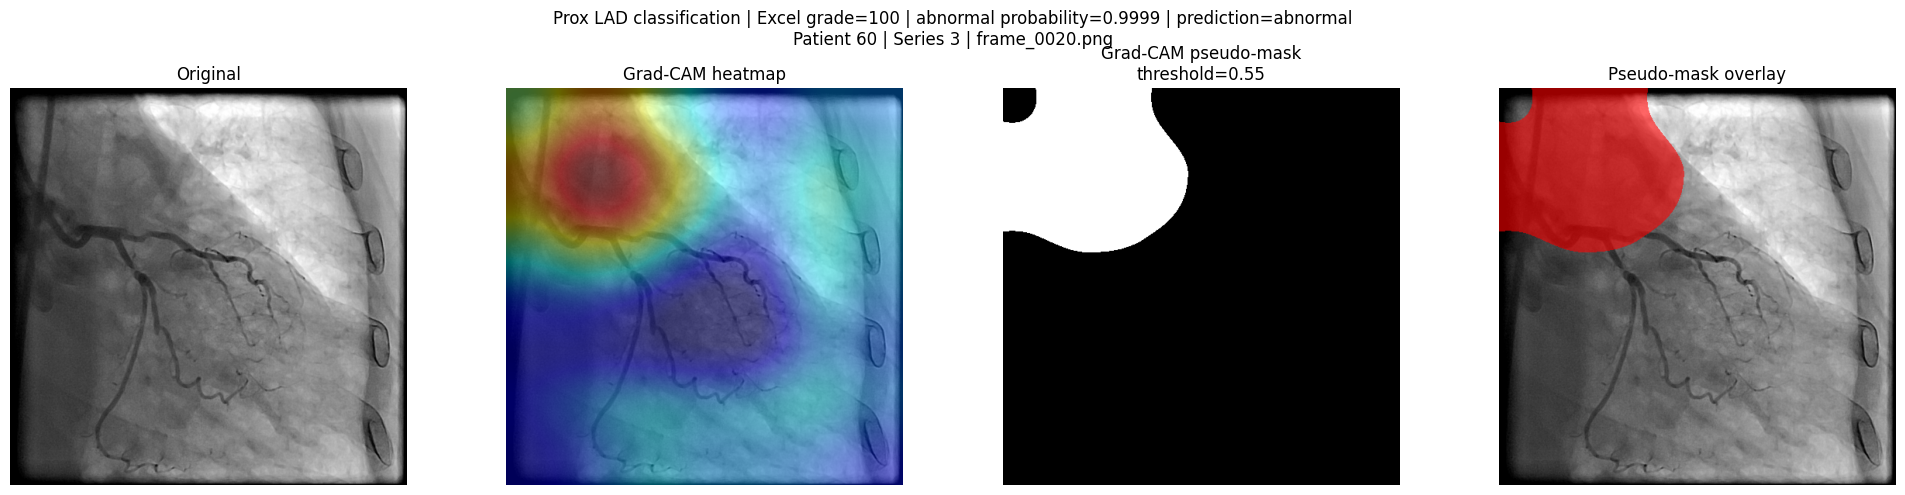

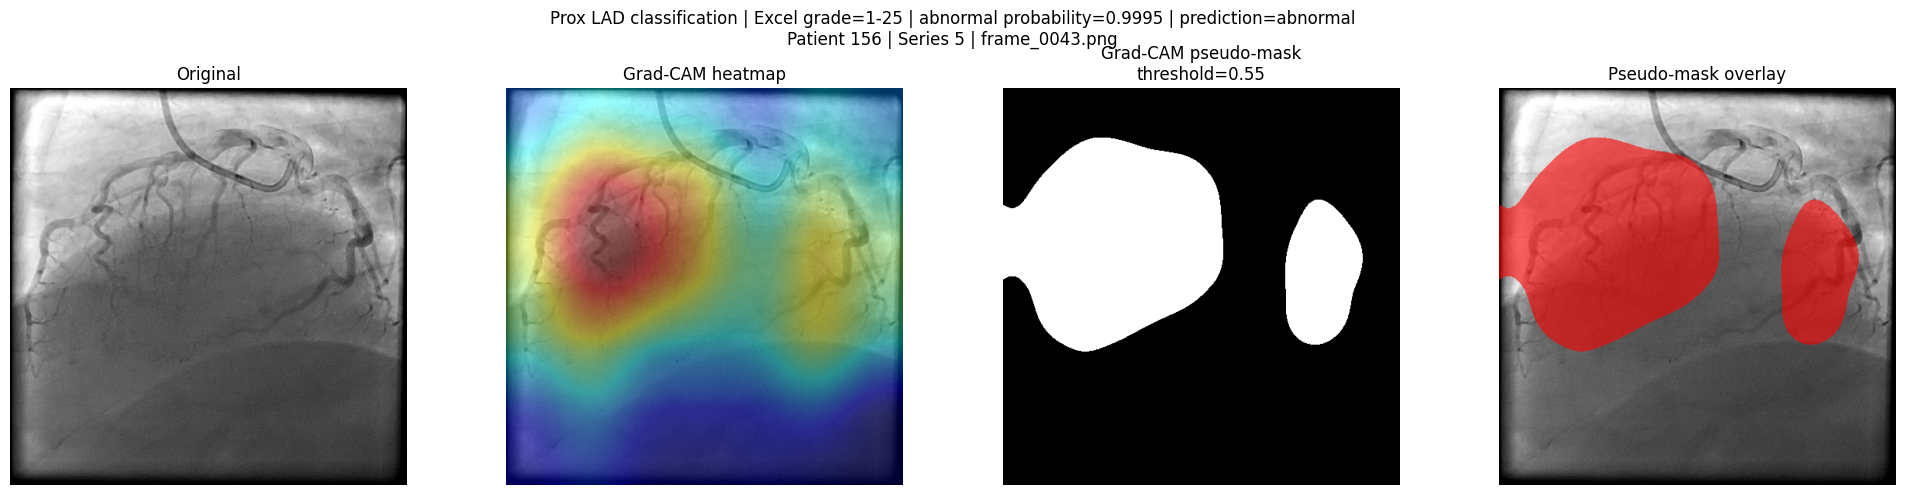

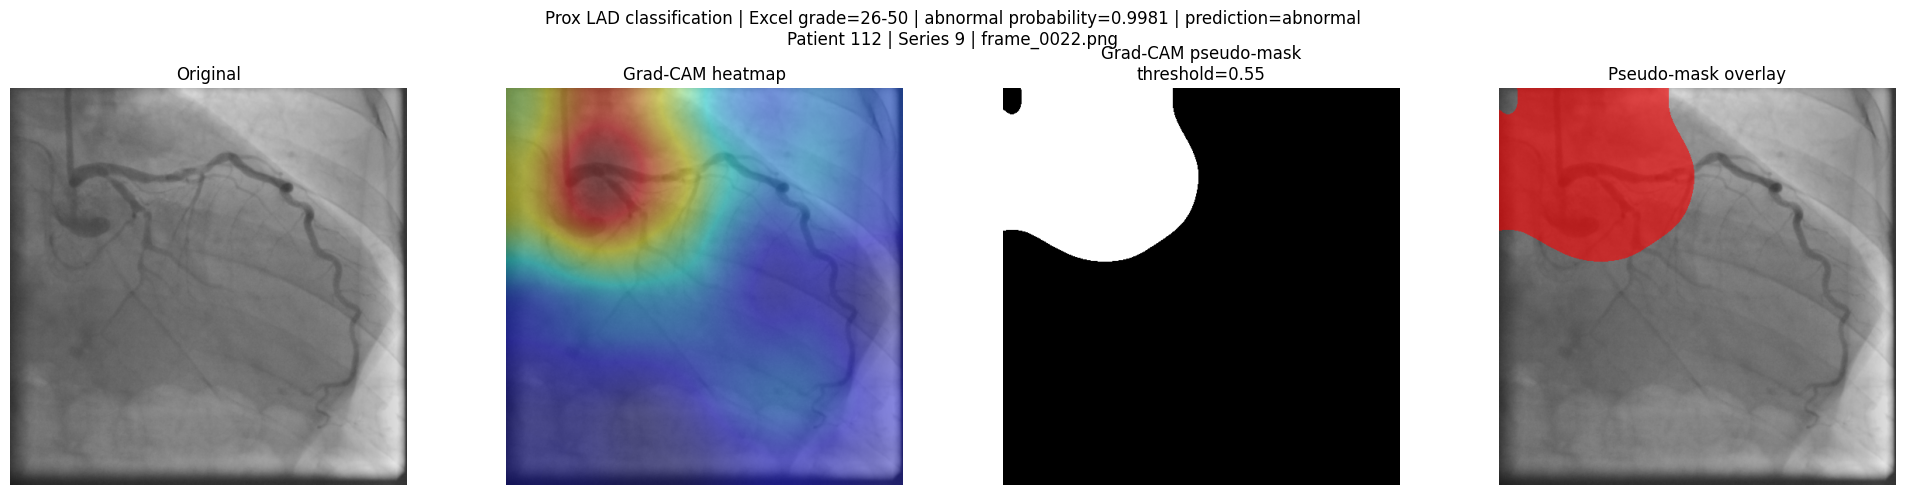

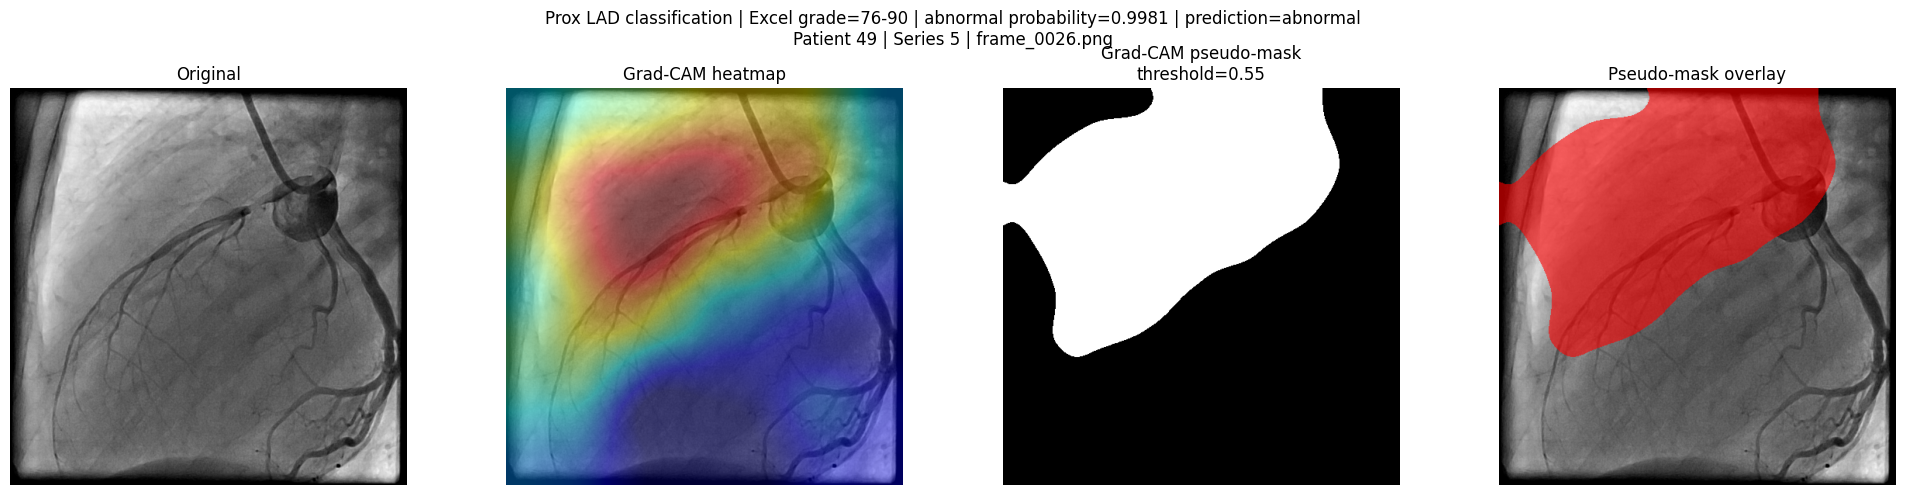

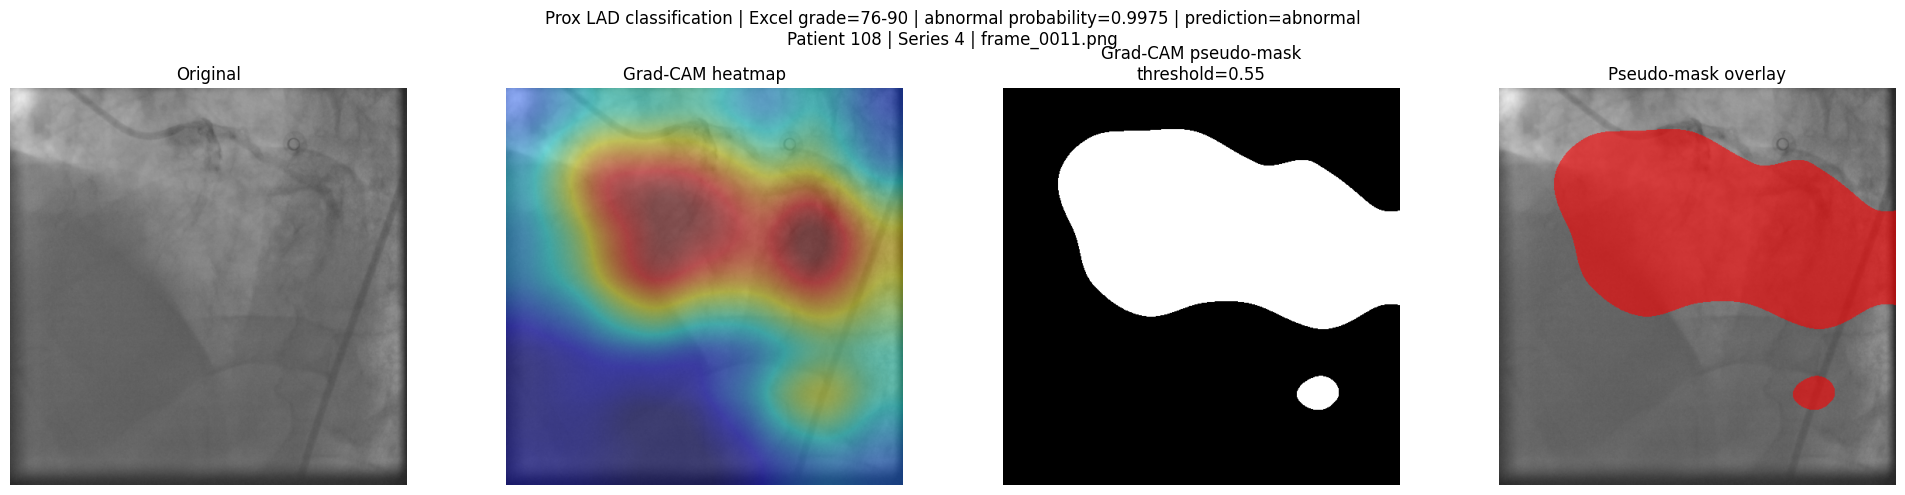

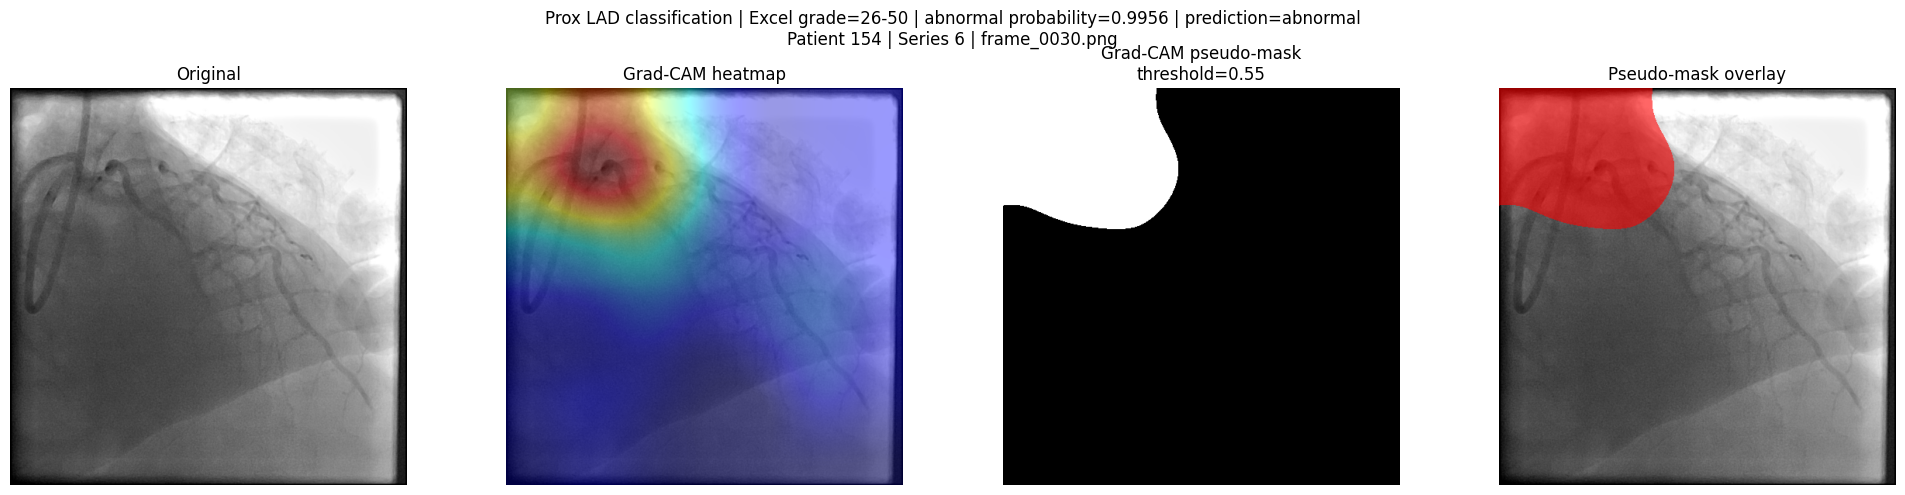


✅ Prox LAD 실험 완료
Model: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/03_best_resnet18.pt
Metrics: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/06_test_metrics.json
Grad-CAM 폴더: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/gradcam_results
Grad-CAM summary: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/hyunkyung/01_classification_gradcam/prox_lad/08_gradcam_summary.csv


,patient_id,series_id,frame_path,target_segment,stenosis_grade,abnormal_probability,predicted_class,predicted_class_name,cam_threshold,mask_pixels,mask_area_ratio,raw_cam_path,heatmap_path,raw_mask_path,pseudo_mask_path,comparison_path
0,60,3,/content/AngioCAD_classification_data/AngioCAD...,Prox LAD,100,0.999864,1,abnormal,0.55,41430,0.158043,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...
1,156,5,/content/AngioCAD_classification_data/AngioCAD...,Prox LAD,1-25,0.999534,1,abnormal,0.55,72106,0.275063,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...
2,112,9,/content/AngioCAD_classification_data/AngioCAD...,Prox LAD,26-50,0.998141,1,abnormal,0.55,47820,0.182419,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...
3,49,5,/content/AngioCAD_classification_data/AngioCAD...,Prox LAD,76-90,0.998086,1,abnormal,0.55,93447,0.356472,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...
4,108,4,/content/AngioCAD_classification_data/AngioCAD...,Prox LAD,76-90,0.997494,1,abnormal,0.55,85831,0.327419,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...
5,154,6,/content/AngioCAD_classification_data/AngioCAD...,Prox LAD,26-50,0.995551,1,abnormal,0.55,36001,0.137333,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...


In [ ]:
#@title 16. Prox LAD Grad-CAM heatmap 및 pseudo-mask 생성

class GradCAM:

    def __init__(
        self,
        model,
        target_layer,
    ):

        self.model = model
        self.target_layer = (
            target_layer
        )

        self.activations = None
        self.gradients = None

        self.forward_handle = (
            self.target_layer
            .register_forward_hook(
                self._forward_hook
            )
        )

    def _save_gradient(
        self,
        gradient,
    ):

        self.gradients = (
            gradient.detach()
        )

    def _forward_hook(
        self,
        module,
        inputs,
        output,
    ):

        self.activations = (
            output.detach()
        )

        output.register_hook(
            self._save_gradient
        )

    def generate(
        self,
        input_tensor,
        target_class=1,
    ):

        self.model.eval()

        self.model.zero_grad(
            set_to_none=True
        )

        logits = self.model(
            input_tensor
        )

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        target_probability = float(
            probabilities[
                0,
                target_class,
            ]
            .detach()
            .cpu()
        )

        predicted_class = int(
            probabilities.argmax(
                dim=1
            )[0]
            .detach()
            .cpu()
        )

        target_logit = logits[
            0,
            target_class,
        ]

        target_logit.backward()


        weights = (
            self.gradients.mean(
                dim=(2, 3),
                keepdim=True,
            )
        )

        cam = (
            weights
            * self.activations
        ).sum(
            dim=1
        )

        cam = torch.relu(
            cam
        )

        cam = (
            cam[0]
            .detach()
            .cpu()
            .numpy()
        )

        cam = (
            cam
            - cam.min()
        )

        if cam.max() > 0:

            cam = (
                cam
                / cam.max()
            )

        return (
            cam,
            target_probability,
            predicted_class,
        )

    def close(self):

        self.forward_handle.remove()


def remove_small_components(
    binary_mask,
    minimum_area,
):

    (
        number_of_labels,
        labels,
        stats,
        _,
    ) = cv2.connectedComponentsWithStats(
        binary_mask.astype(
            np.uint8
        ),
        connectivity=8,
    )

    cleaned_mask = np.zeros_like(
        binary_mask,
        dtype=np.uint8,
    )

    for component_id in range(
        1,
        number_of_labels,
    ):

        component_area = stats[
            component_id,
            cv2.CC_STAT_AREA,
        ]

        if (
            component_area
            >= minimum_area
        ):

            cleaned_mask[
                labels
                == component_id
            ] = 1

    return cleaned_mask


def cam_to_binary_mask(
    cam,
    output_width,
    output_height,
):

    resized_cam = cv2.resize(
        cam,
        (
            output_width,
            output_height,
        ),
        interpolation=cv2.INTER_CUBIC,
    )

    resized_cam = np.clip(
        resized_cam,
        0,
        1,
    )

    raw_binary_mask = (
        resized_cam
        >= CAM_THRESHOLD
    ).astype(
        np.uint8
    )

    kernel = (
        cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (7, 7),
        )
    )

    cleaned_mask = (
        cv2.morphologyEx(
            raw_binary_mask,
            cv2.MORPH_CLOSE,
            kernel,
            iterations=2,
        )
    )

    cleaned_mask = (
        cv2.morphologyEx(
            cleaned_mask,
            cv2.MORPH_OPEN,
            kernel,
            iterations=1,
        )
    )

    minimum_area = max(
        10,
        int(
            output_width
            * output_height
            * MIN_COMPONENT_AREA_RATIO
        ),
    )

    cleaned_mask = (
        remove_small_components(
            cleaned_mask,
            minimum_area,
        )
    )

    return (
        resized_cam,
        raw_binary_mask,
        cleaned_mask,
    )


# --------------------------------------------------
# 실제 abnormal 환자 중 확률 상위 6명
# --------------------------------------------------

positive_test_df = (
    prediction_df[
        prediction_df["label"]
        == 1
    ]
    .sort_values(
        "probability_abnormal",
        ascending=False,
    )
    .drop_duplicates(
        subset=[
            "patient_id"
        ]
    )
    .head(
        NUM_CAM_EXAMPLES
    )
    .reset_index(
        drop=True
    )
)


assert len(
    positive_test_df
) > 0, (
    "Test set에 Prox LAD abnormal sample이 없습니다."
)


print(
    "Grad-CAM 생성 대상:",
    len(positive_test_df),
    "개",
)

display(
    positive_test_df[
        [
            "patient_id",
            "series_id",
            "stenosis_grade",
            "probability_abnormal",
            "prediction",
            "frame_path",
        ]
    ]
)


gradcam = GradCAM(
    model=model,
    target_layer=model.layer4[-1],
)

gradcam_summary = []


for _, row in (
    positive_test_df.iterrows()
):

    image_path = Path(
        row["frame_path"]
    )

    original_image = (
        Image.open(
            image_path
        ).convert("RGB")
    )

    original_rgb = np.array(
        original_image
    )

    (
        original_height,
        original_width,
    ) = original_rgb.shape[:2]


    input_tensor = (
        evaluation_transform(
            original_image
        )
        .unsqueeze(0)
        .to(DEVICE)
    )


    (
        raw_cam,
        abnormal_probability,
        predicted_class,
    ) = gradcam.generate(
        input_tensor,
        target_class=1,
    )


    (
        resized_cam,
        raw_binary_mask,
        cleaned_binary_mask,
    ) = cam_to_binary_mask(
        raw_cam,
        output_width=original_width,
        output_height=original_height,
    )


    heatmap_uint8 = (
        resized_cam
        * 255
    ).astype(
        np.uint8
    )

    heatmap_bgr = (
        cv2.applyColorMap(
            heatmap_uint8,
            cv2.COLORMAP_JET,
        )
    )

    heatmap_rgb = (
        cv2.cvtColor(
            heatmap_bgr,
            cv2.COLOR_BGR2RGB,
        )
    )

    heatmap_overlay = (
        cv2.addWeighted(
            original_rgb,
            0.60,
            heatmap_rgb,
            0.40,
            0,
        )
    )


    pseudo_mask_overlay = (
        original_rgb.copy()
    )

    mask_boolean = (
        cleaned_binary_mask
        .astype(bool)
    )

    red_color = np.zeros_like(
        original_rgb
    )

    red_color[:, :, 0] = 255

    pseudo_mask_overlay[
        mask_boolean
    ] = (
        0.40
        * pseudo_mask_overlay[
            mask_boolean
        ]
        + 0.60
        * red_color[
            mask_boolean
        ]
    ).astype(
        np.uint8
    )


    sample_name = (
        f"patient_{int(row['patient_id']):03d}"
        f"_series_{int(row['series_id']):02d}"
        f"_{image_path.stem}"
    )


    raw_cam_npy_path = (
        GRADCAM_OUTPUT_DIR
        / f"{sample_name}_gradcam.npy"
    )

    heatmap_png_path = (
        GRADCAM_OUTPUT_DIR
        / f"{sample_name}_heatmap.png"
    )

    raw_mask_path = (
        GRADCAM_OUTPUT_DIR
        / f"{sample_name}_raw_mask.png"
    )

    cleaned_mask_path = (
        GRADCAM_OUTPUT_DIR
        / f"{sample_name}_pseudo_mask.png"
    )

    comparison_path = (
        GRADCAM_OUTPUT_DIR
        / f"{sample_name}_comparison.png"
    )


    np.save(
        raw_cam_npy_path,
        resized_cam.astype(
            np.float32
        ),
    )

    Image.fromarray(
        heatmap_uint8
    ).save(
        heatmap_png_path
    )

    Image.fromarray(
        raw_binary_mask * 255
    ).save(
        raw_mask_path
    )

    Image.fromarray(
        cleaned_binary_mask * 255
    ).save(
        cleaned_mask_path
    )


    figure, axes = plt.subplots(
        1,
        4,
        figsize=(20, 5),
    )


    axes[0].imshow(
        original_rgb
    )

    axes[0].set_title(
        "Original"
    )


    axes[1].imshow(
        heatmap_overlay
    )

    axes[1].set_title(
        "Grad-CAM heatmap"
    )


    axes[2].imshow(
        cleaned_binary_mask,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[2].set_title(
        "Grad-CAM pseudo-mask\n"
        f"threshold={CAM_THRESHOLD}"
    )


    axes[3].imshow(
        pseudo_mask_overlay
    )

    axes[3].set_title(
        "Pseudo-mask overlay"
    )


    for axis in axes:
        axis.axis("off")


    figure.suptitle(
        f"Prox LAD classification | "
        f"Excel grade={row['stenosis_grade']} | "
        f"abnormal probability={abnormal_probability:.4f} | "
        f"prediction={CLASS_NAMES[predicted_class]}\n"
        f"Patient {int(row['patient_id'])} | "
        f"Series {int(row['series_id'])} | "
        f"{image_path.name}",
        fontsize=12,
    )


    plt.tight_layout()

    plt.savefig(
        comparison_path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)


    mask_pixels = int(
        cleaned_binary_mask.sum()
    )

    mask_area_ratio = float(
        cleaned_binary_mask.mean()
    )


    gradcam_summary.append(
        {
            "patient_id": int(
                row["patient_id"]
            ),

            "series_id": int(
                row["series_id"]
            ),

            "frame_path": str(
                image_path
            ),

            "target_segment": (
                TARGET_SEGMENT
            ),

            "stenosis_grade": str(
                row["stenosis_grade"]
            ),

            "abnormal_probability": float(
                abnormal_probability
            ),

            "predicted_class": int(
                predicted_class
            ),

            "predicted_class_name": (
                CLASS_NAMES[
                    predicted_class
                ]
            ),

            "cam_threshold": float(
                CAM_THRESHOLD
            ),

            "mask_pixels": (
                mask_pixels
            ),

            "mask_area_ratio": (
                mask_area_ratio
            ),

            "raw_cam_path": str(
                raw_cam_npy_path
            ),

            "heatmap_path": str(
                heatmap_png_path
            ),

            "raw_mask_path": str(
                raw_mask_path
            ),

            "pseudo_mask_path": str(
                cleaned_mask_path
            ),

            "comparison_path": str(
                comparison_path
            ),
        }
    )


gradcam.close()


gradcam_summary_df = pd.DataFrame(
    gradcam_summary
)

gradcam_summary_df.to_csv(
    GRADCAM_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)


print("\n✅ Prox LAD 실험 완료")
print("Model:", BEST_MODEL_PATH)
print("Metrics:", METRICS_PATH)
print("Grad-CAM 폴더:", GRADCAM_OUTPUT_DIR)
print("Grad-CAM summary:", GRADCAM_SUMMARY_PATH)

display(
    gradcam_summary_df
)